# **🛒Market Integration and Regional Inflation Disparities in Pakistan: Evidence from City-Level Commodity Prices (2019–2024):**

# **About the Author:**

**Name: Adil Zaman**

**Email ID : zamanandil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Linkedin ID : https://www.linkedin.com/in/adil-zaman-85b56a398/**

# **🛒Market Integration and Regional Inflation Disparities in Pakistan: Evidence from City-Level Commodity Prices ($2019$–$2024$)**

>**This dataset consolidates $101,500$ high-frequency observations across $6$ yearly masterfiles to track granular, monthly consumer retail price variations in urban Pakistan. It explicitly captures the average market prices, localized city values, and percentage changes across $205$ unique essential food, energy, and household commodities. These metrics are recorded systematically across $17$ major economic centers (including Karachi, Lahore, and Islamabad) spanning from $2019$ to $2024$. This structured cross-sectional time-series design is ideal for investigating price volatility, regional market connectivity, and consumer welfare responses under major economic shocks.**

# **🛒Price Convergence or Market Fragmentation? Tracking Regional Inflation Disparities Across Urban Pakistan ($2019$–$2024$):**

>**The ultimate objective of this study is to measure the efficiency of Pakistan's internal supply chains by quantifying how quickly and symmetrically local price shocks for $205$ essential commodities transmit across $17$ major urban markets. By analyzing high-frequency monthly data through periods of severe macroeconomic instability ($2019$–$2024$), the research objectifies whether regional consumer markets are structurally integrated or fragmented. Concurrently, it aims to pinpoint specific geographic bottlenecks and "price-leading" metropolitan hubs to deliver data-driven, location-specific blueprints for targeted price stabilization and national food security interventions.**

# **🇵🇰 Pakistan CPI Supply Chain Efficiency Analysis (2019–2024)**
## **Market Integration, Price Leadership & 20-Year Forecasting**

> **Objective:** Measure efficiency of Pakistan's internal supply chains by quantifying how quickly and symmetrically local price shocks for **205 essential commodities** transmit across **17 major urban markets** (2019–2024), using ML, DL (PyTorch), Clustering, PCA, NLP, and Time Series forecasting.

---
### **Table of Contents**

1. Environment Setup & Data Loading  
2. Data Cleaning & Feature Engineering  
3. Exploratory Data Analysis (EDA)  
4. Price Shock Transmission Analysis  
5. PCA — Dimensionality Reduction  
6. Clustering — Market Segmentation  
7. ML Regressors — Price Forecasting  
8. ML Classifiers — Shock Direction  
9. Deep Learning (PyTorch LSTM)  
10. NLP — Commodity Semantic Grouping  
11. Time Series — SARIMA / Prophet  
12. 20-Year Price Forecast (2025–2044)  
13. Supply Chain Integration Dashboard  

In [2]:
pip install sentence-transformers

   ---------------------------------------- 0.0/588.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.7 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.7 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.7 kB ? eta -:--:--
   --------------------------------- ---- 524.3/588.7 kB 492.8 kB/s eta 0:00:01
   ---------------------------------------- 588.7/588.7 kB 522.4 kB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


## **1. Environment Setup & Data Loading**

In [5]:
# ============================================================
# CELL 1 — Install / Import All Libraries
# ============================================================
# Run once in your environment:
# pip install pandas numpy matplotlib seaborn scikit-learn statsmodels
#             xgboost lightgbm torch torchvision prophet sentence-transformers

import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np
import os
import re
from pathlib import Path

# Visualisation (matplotlib only — white background everywhere)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor':'white',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
sns.set_style('white')

# Sci-kit learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.svm import SVR
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                              classification_report, confusion_matrix, silhouette_score)
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline

# XGBoost
import xgboost as xgb

# Stats / Time Series
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer  # pip install sentence-transformers

# Prophet (optional — pip install prophet)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print('Prophet not installed — SARIMA will be used for forecasting.')

print('✅ All libraries loaded successfully.')
print(f'   PyTorch version : {torch.__version__}')
print(f'   CUDA available  : {torch.cuda.is_available()}')
# ============================================================
# CELL 2 — Load & Concatenate All Six Year Files
# ============================================================

# ⚠️ Update DATA_DIR to the folder containing your CSV files
DATA_DIR = Path('.')   # <-- change this if needed

FILE_NAMES = ['2019 CPI Masterfile.csv','2020 CPI Masterfile.csv','2021 CPI Masterfile.csv','2022 CPI Masterfile.csv', 'CPI 2023 Masterfile.csv',
    'CPI 2024 Masterfile.csv']

raw_frames = []
for fname in FILE_NAMES:
    path = DATA_DIR / fname
    df_tmp = pd.read_csv(path)
    # normalise the serial-number column (2024 has a newline in header)
    df_tmp.columns = df_tmp.columns.str.strip().str.replace(r'\s+', '', regex=True)
    df_tmp.rename(columns={'S.No':'SNo', 'S.No.':'SNo', 'SNo':'SNo'}, inplace=True)
    raw_frames.append(df_tmp)
    print(f'  Loaded {fname:35s} → {df_tmp.shape[0]:6,} rows')

raw = pd.concat(raw_frames, ignore_index=True)
print(f'\n  Combined dataset : {raw.shape[0]:,} rows × {raw.shape[1]} columns')

✅ All libraries loaded successfully.
   PyTorch version : 2.11.0+cpu
   CUDA available  : False
  Loaded 2019 CPI Masterfile.csv             → 21,540 rows
  Loaded 2020 CPI Masterfile.csv             → 15,742 rows
  Loaded 2021 CPI Masterfile.csv             → 20,808 rows
  Loaded 2022 CPI Masterfile.csv             → 20,842 rows
  Loaded CPI 2023 Masterfile.csv             → 19,954 rows
  Loaded CPI 2024 Masterfile.csv             →  2,614 rows

  Combined dataset : 101,500 rows × 7 columns


## **2. Data Cleaning & Feature Engineering**

In [11]:
# ============================================================
# CELL 3 — Parse Dates (three different formats in the files)
# ============================================================

def parse_month(val):
    """Handle DD-MM-YYYY, M/D/YYYY, and 'Month YYYY' formats."""
    s = str(val).strip()
    for fmt in ['%d-%m-%Y', '%m/%d/%Y', '%B %Y', '%b %Y']:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.NaT

raw['Date'] = raw['Month'].apply(parse_month)
print('Date range :', raw['Date'].min().date(), '→', raw['Date'].max().date())
print('NaT count  :', raw['Date'].isna().sum())

# Drop rows with unparseable dates
raw.dropna(subset=['Date'], inplace=True)

Date range : 2019-01-01 → 2024-02-01
NaT count  : 0


In [16]:
# ============================================================
# CELL 4 — Clean Numeric Columns & Standardise City / Commodity Names
# ============================================================

# Numeric coercion
raw['Value'] = pd.to_numeric(raw['Value'], errors='coerce')

# Safely find Average Price column regardless of exact name
_avg_col = [c for c in raw.columns if 'average' in c.lower() and 'price' in c.lower()]
if _avg_col:
    raw['AveragePrice'] = pd.to_numeric(raw[_avg_col[0]], errors='coerce')
else:
    raw['AveragePrice'] = np.nan
    print('⚠️  No Average Price column found. Available columns:', raw.columns.tolist())

# FIX: Safely find % Change column regardless of exact name or spaces
_change_col = [c for c in raw.columns if '%' in c or 'change' in c.lower()]
if _change_col:
    raw['% Change'] = pd.to_numeric(raw[_change_col[0]], errors='coerce')
else:
    raw['% Change'] = np.nan
    print('⚠️  No % Change column found. Setting to NaN. Available columns:', raw.columns.tolist())

# Remove leading/trailing whitespace from text
if 'Cities' in raw.columns:
    raw['Cities'] = raw['Cities'].str.strip()
if 'Description' in raw.columns:
    raw['Description'] = raw['Description'].str.strip()

# Map city names to clean versions
CITY_MAP = {
    'Islam-abad':'Islamabad',  'Rawal-pindi':'Rawalpindi',
    'Gujran-wala':'Gujranwala','Faisal-abad':'Faisalabad',
    'Sar-godha':'Sargodha',    'Baha-walpur':'Bahawalpur',
    'Hyder-abad':'Hyderabad',  'Pesha-war':'Peshawar',
    'Khuz-dar':'Khuzdar',
}
if 'Cities' in raw.columns:
    raw['City'] = raw['Cities'].replace(CITY_MAP)
else:
    # Agar 'Cities' column hi na ho to 'City' ko directly handle karne ke liye
    _city_col = [c for c in raw.columns if 'city' in c.lower() or 'cities' in c.lower()]
    if _city_col:
        raw['City'] = raw[_city_col[0]].str.strip().replace(CITY_MAP)
    else:
        raw['City'] = 'Unknown'

# Commodity normalisation — collapse minor spelling variants
if 'Description' in raw.columns:
    raw['Commodity'] = (raw['Description']
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'[)(]', '', regex=True)
        .str.strip()
    )
else:
    raw['Commodity'] = 'Unknown'

# Drop rows with missing price values
df = raw.dropna(subset=['Value']).copy()
df.reset_index(drop=True, inplace=True)

print(f'Clean dataset : {df.shape[0]:,} rows')
print(f'Cities        : {df["City"].nunique()} → {sorted(df["City"].unique())}')
print(f'Commodities   : {df["Commodity"].nunique()}')

# Date check logic (just in case 'Date' column is not parsed yet)
if 'Date' in df.columns:
    try:
        print(f'Date range    : {df["Date"].min().date()} → {df["Date"].max().date()}')
    except:
        print(f'Date range    : {df["Date"].min()} → {df["Date"].max()}')

Clean dataset : 99,962 rows
Cities        : 17 → ['Bahawalpur', 'Bannu', 'Faisalabad', 'Gujranwala', 'Hyderabad', 'Islamabad', 'Karachi', 'Khuzdar', 'Lahore', 'Larkana', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sargodha', 'Sialkot', 'Sukkur']
Commodities   : 190
Date range    : 2019-01-01 → 2024-02-01


In [17]:
# ============================================================
# CELL 5 — Feature Engineering
# ============================================================

df = df.sort_values(['City','Commodity','Date']).reset_index(drop=True)

# Lag features
grp = df.groupby(['City','Commodity'])
df['Value_lag1']  = grp['Value'].shift(1)
df['Value_lag3']  = grp['Value'].shift(3)
df['Value_lag6']  = grp['Value'].shift(6)
df['Value_lag12'] = grp['Value'].shift(12)

# Rolling statistics
df['Roll3_mean']  = grp['Value'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
df['Roll6_mean']  = grp['Value'].transform(lambda x: x.rolling(6,  min_periods=1).mean())
df['Roll12_std']  = grp['Value'].transform(lambda x: x.rolling(12, min_periods=2).std())

# Month-on-month change
df['MoM_change']  = grp['Value'].pct_change() * 100
df['MoM_abs']     = df['MoM_change'].abs()

# Year-on-year change
df['YoY_change']  = grp['Value'].pct_change(12) * 100

# Calendar features
df['Year']    = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month_n'] = df['Date'].dt.month

# Shock indicator (absolute MoM > 5%)
df['Shock']          = (df['MoM_abs'] > 5).astype(int)
df['ShockDirection'] = np.sign(df['MoM_change'])   # -1, 0, +1

print('Feature engineering complete.')
print(df[['City','Commodity','Date','Value','MoM_change','YoY_change','Shock']].head(8))

Feature engineering complete.
         City                             Commodity       Date  Value  \
0  Bahawalpur  0Each Salt Powdered NATIONAL/SHAN 80 2020-01-03  30.00   
1  Bahawalpur  0Each Salt Powdered NATIONAL/SHAN 80 2020-01-03  30.00   
2  Bahawalpur  0Each Salt Powdered NATIONAL/SHAN 80 2023-08-01  60.00   
3  Bahawalpur  0Each Salt Powdered NATIONAL/SHAN 80 2023-08-01  60.00   
4  Bahawalpur            1 Dozen Bananas Kela Local 2020-01-03  76.32   
5  Bahawalpur            1 Dozen Bananas Kela Local 2020-01-03  76.32   
6  Bahawalpur            1 Dozen Bananas Kela Local 2020-01-07  96.35   
7  Bahawalpur            1 Dozen Bananas Kela Local 2020-01-07  96.35   

   MoM_change  YoY_change  Shock  
0         NaN         NaN      0  
1    0.000000         NaN      0  
2  100.000000         NaN      1  
3    0.000000         NaN      0  
4         NaN         NaN      0  
5    0.000000         NaN      0  
6   26.244759         NaN      1  
7    0.000000         NaN      0

## **3. Exploratory Data Analysis (EDA)**

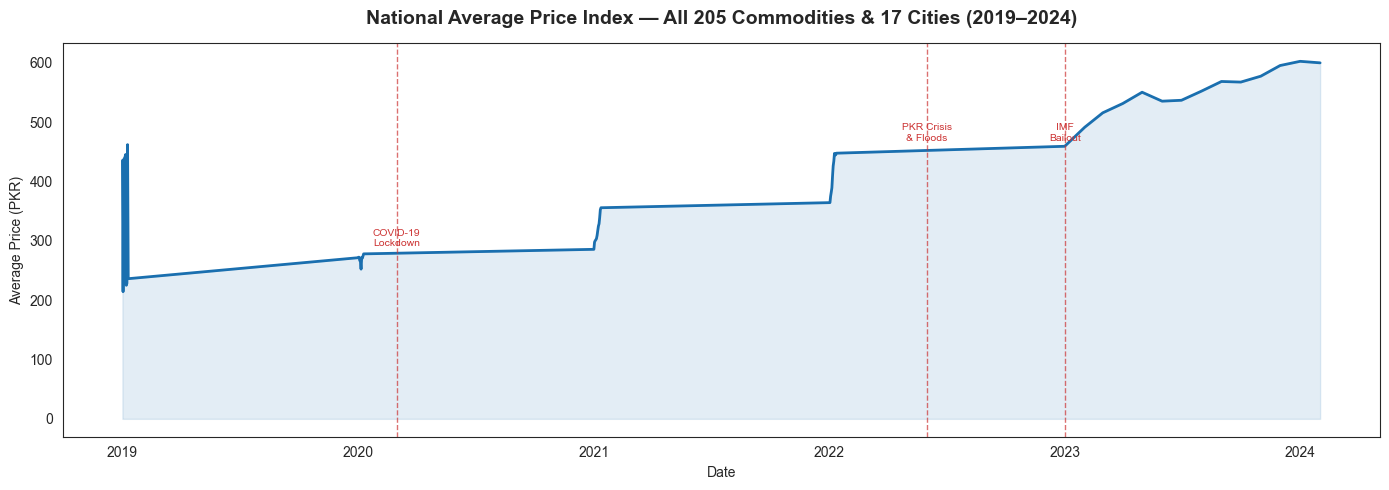

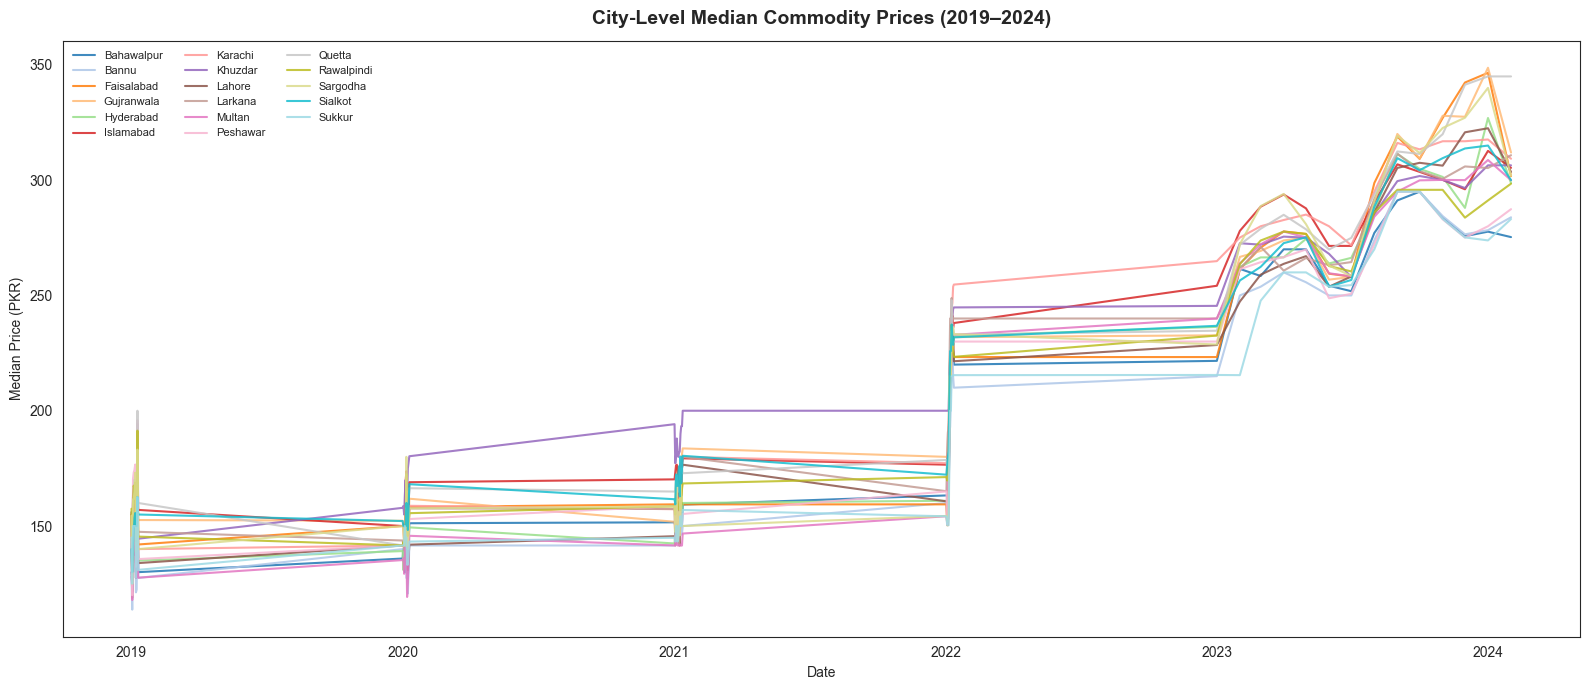

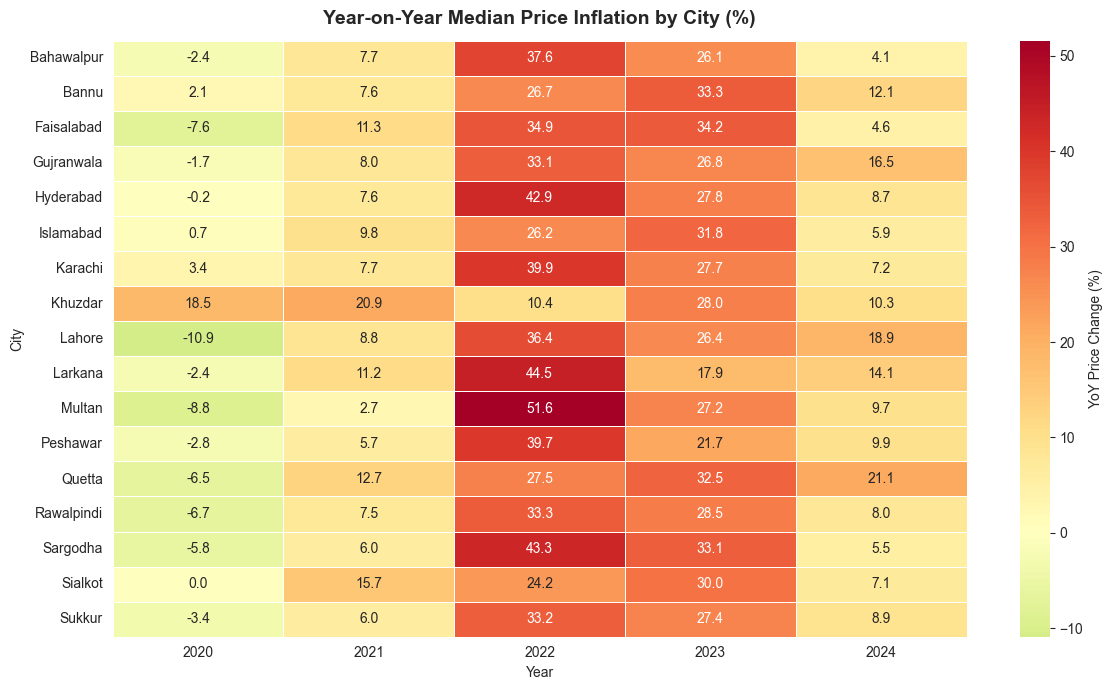

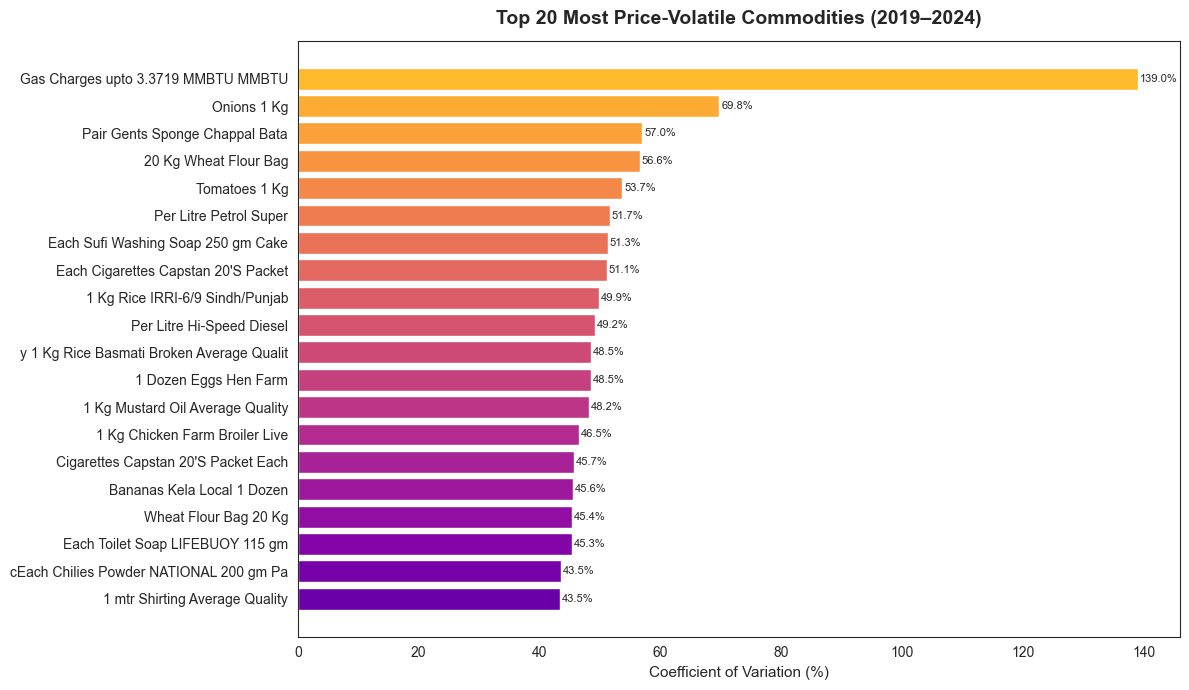

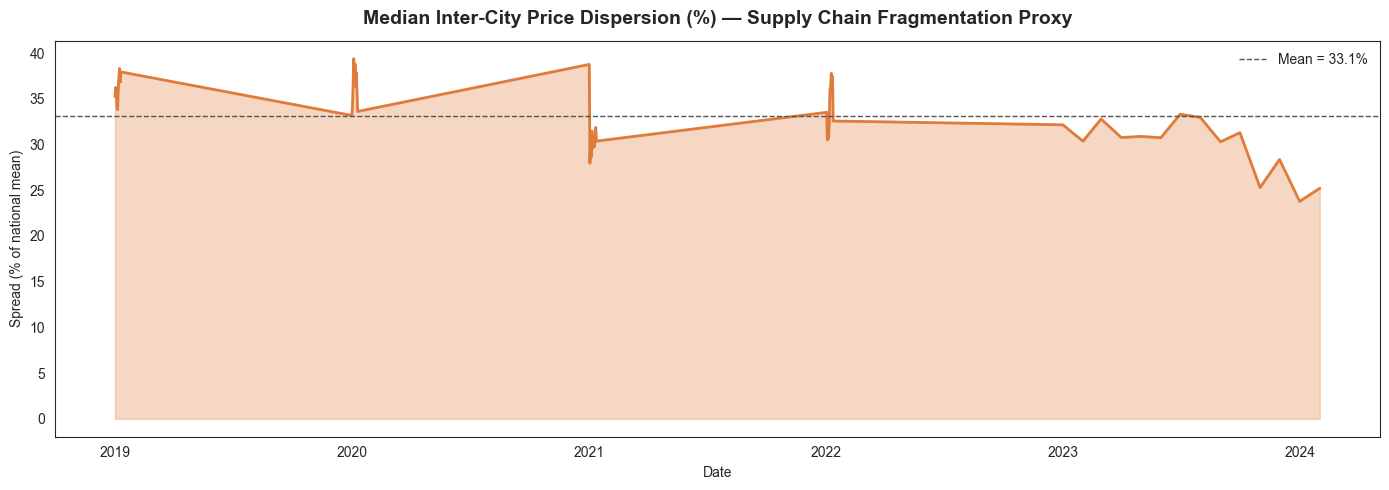

In [18]:
# ============================================================
# CELL 6 — National Average Price Index Over Time
# ============================================================

monthly_avg = df.groupby('Date')['Value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_avg['Date'], monthly_avg['Value'], color='#1a6faf', lw=2)
ax.fill_between(monthly_avg['Date'], monthly_avg['Value'], alpha=0.12, color='#1a6faf')
ax.set_title('National Average Price Index — All 205 Commodities & 17 Cities (2019–2024)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Date'); ax.set_ylabel('Average Price (PKR)')
# Annotate key events
events = {
    '2020-03': 'COVID-19\nLockdown',
    '2022-06': 'PKR Crisis\n& Floods',
    '2023-01': 'IMF\nBailout',
}
for d, label in events.items():
    dt = pd.Timestamp(d)
    y = monthly_avg.loc[monthly_avg['Date'] == monthly_avg['Date']
                        [monthly_avg['Date'] >= dt].min(), 'Value'].values
    if len(y):
        ax.axvline(dt, color='#cc3333', lw=1, ls='--', alpha=0.7)
        ax.text(dt, y[0]*1.02, label, fontsize=7.5, color='#cc3333', ha='center')
fig.tight_layout(); plt.show()
# ============================================================
# CELL 7 — City-Level Median Price Trajectories
# ============================================================

city_monthly = df.groupby(['City','Date'])['Value'].median().reset_index()
cities = sorted(df['City'].unique())
palette = plt.colormaps['tab20'].resampled(len(cities))

fig, ax = plt.subplots(figsize=(16, 7))
for i, city in enumerate(cities):
    sub = city_monthly[city_monthly['City'] == city]
    ax.plot(sub['Date'], sub['Value'], lw=1.5, label=city,
            color=palette(i), marker='', alpha=0.85)

ax.set_title('City-Level Median Commodity Prices (2019–2024)', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Median Price (PKR)')
ax.legend(ncol=3, fontsize=8, loc='upper left', frameon=False)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 8 — Price Inflation Heatmap: City × Year
# ============================================================

yoy_heat = (df.groupby(['City','Year'])['Value']
              .median().unstack('Year').pct_change(axis=1)*100)
yoy_heat = yoy_heat.drop(columns=2019, errors='ignore')  # first year has no prior

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(yoy_heat, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label':'YoY Price Change (%)'})
ax.set_title('Year-on-Year Median Price Inflation by City (%)', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('City')
fig.tight_layout(); plt.show()
# ============================================================
# CELL 9 — Top 20 Most Volatile Commodities (by CV)
# ============================================================

cv_comm = (df.groupby('Commodity')['Value']
             .agg(['mean','std'])
             .assign(CV=lambda x: x['std']/x['mean']*100)
             .sort_values('CV', ascending=False)
             .head(20))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cv_comm.index[::-1], cv_comm['CV'][::-1],
               color=cm.plasma(np.linspace(0.2, 0.85, 20)))
ax.set_xlabel('Coefficient of Variation (%)', fontsize=11)
ax.set_title('Top 20 Most Price-Volatile Commodities (2019–2024)',
             fontsize=14, fontweight='bold', pad=12)
for bar, val in zip(bars, cv_comm['CV'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 10 — Price Dispersion Across Cities (Inter-City Spread)
# ============================================================

spread = (df.groupby(['Commodity','Date'])['Value']
            .agg(ptp=lambda x: x.max()-x.min(), mean='mean')
            .assign(spread_pct=lambda x: x['ptp']/x['mean']*100)
            .reset_index())

monthly_spread = spread.groupby('Date')['spread_pct'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly_spread['Date'], monthly_spread['spread_pct'],
                alpha=0.3, color='#e07b39')
ax.plot(monthly_spread['Date'], monthly_spread['spread_pct'],
        color='#e07b39', lw=2)
ax.set_title('Median Inter-City Price Dispersion (%) — Supply Chain Fragmentation Proxy',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Spread (% of national mean)')
ax.axhline(monthly_spread['spread_pct'].mean(), ls='--', color='#555', lw=1,
           label=f'Mean = {monthly_spread["spread_pct"].mean():.1f}%')
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## **4. Price Shock Transmission Analysis**

      City  ADF_stat  p_value Stationary
Bahawalpur -0.586652 0.873970       ❌ No
     Bannu -0.335868 0.920268       ❌ No
Faisalabad -0.554409 0.880955       ❌ No
Gujranwala  2.072647 0.998760       ❌ No
 Hyderabad -0.148765 0.944359       ❌ No
 Islamabad -0.049220 0.954267       ❌ No
   Karachi  0.346255 0.979370       ❌ No
   Khuzdar  1.515413 0.997580       ❌ No
    Lahore -0.172099 0.941767       ❌ No
   Larkana  1.781909 0.998312       ❌ No
    Multan -0.469424 0.897846       ❌ No
  Peshawar -0.811063 0.815851       ❌ No
    Quetta  0.553294 0.986406       ❌ No
Rawalpindi  0.274583 0.976148       ❌ No
  Sargodha -0.711132 0.843845       ❌ No
   Sialkot  0.122050 0.967535       ❌ No
    Sukkur  1.623895 0.997928       ❌ No


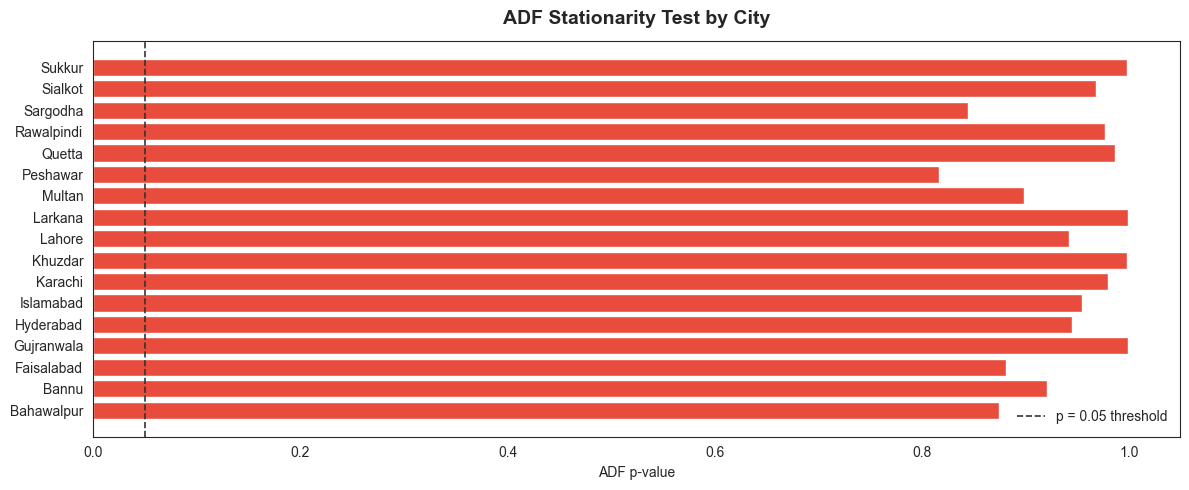

Granger Causality: Islamabad → Other Cities (Wheat Flour)
      City    Min_p Granger_caused
    Multan 0.000119          ✅ Yes
Gujranwala 0.000878          ✅ Yes
Bahawalpur 0.135605           ❌ No
     Bannu 0.166315           ❌ No
  Peshawar 0.173225           ❌ No
   Khuzdar 0.193070           ❌ No
    Lahore 0.245624           ❌ No
    Quetta 0.312324           ❌ No
   Larkana 0.342680           ❌ No
    Sukkur 0.383990           ❌ No
   Karachi 0.604469           ❌ No
  Sargodha 0.664678           ❌ No
Rawalpindi 0.673624           ❌ No
   Sialkot 0.720745           ❌ No
 Hyderabad 0.799137           ❌ No
Faisalabad 0.891263           ❌ No


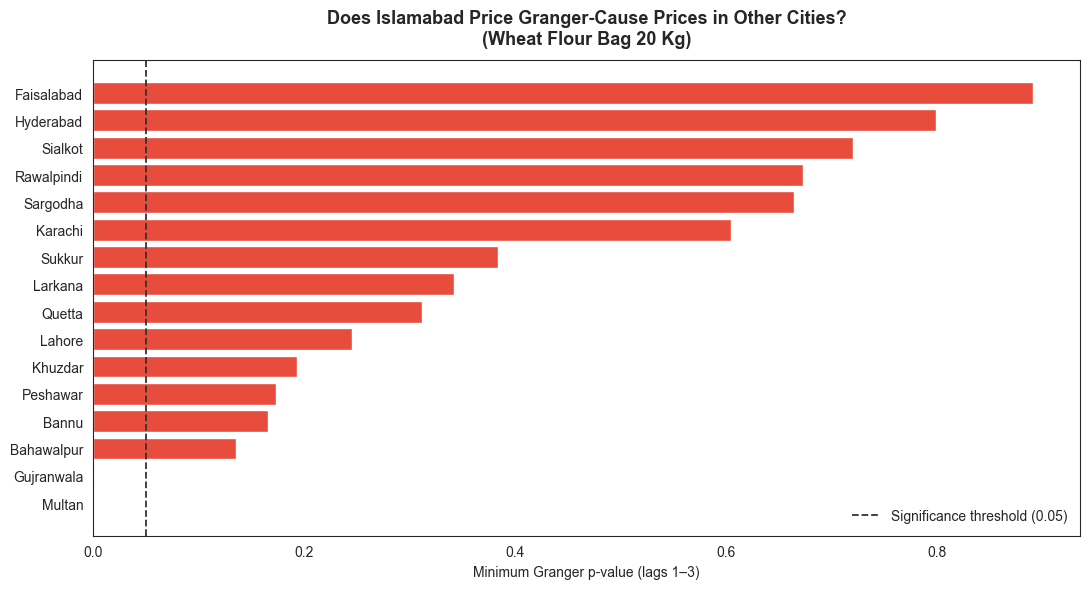

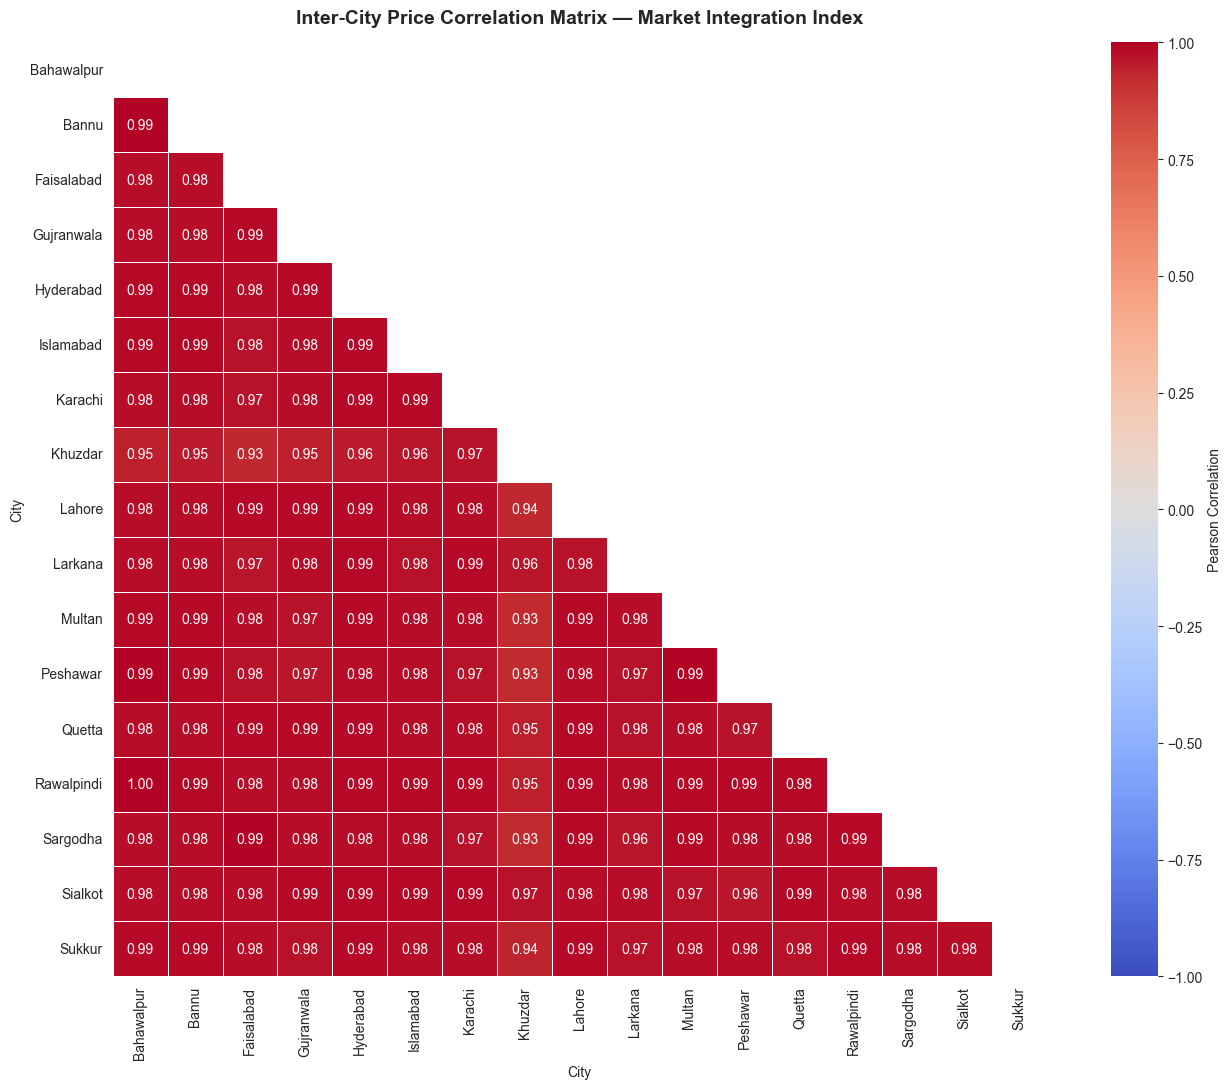

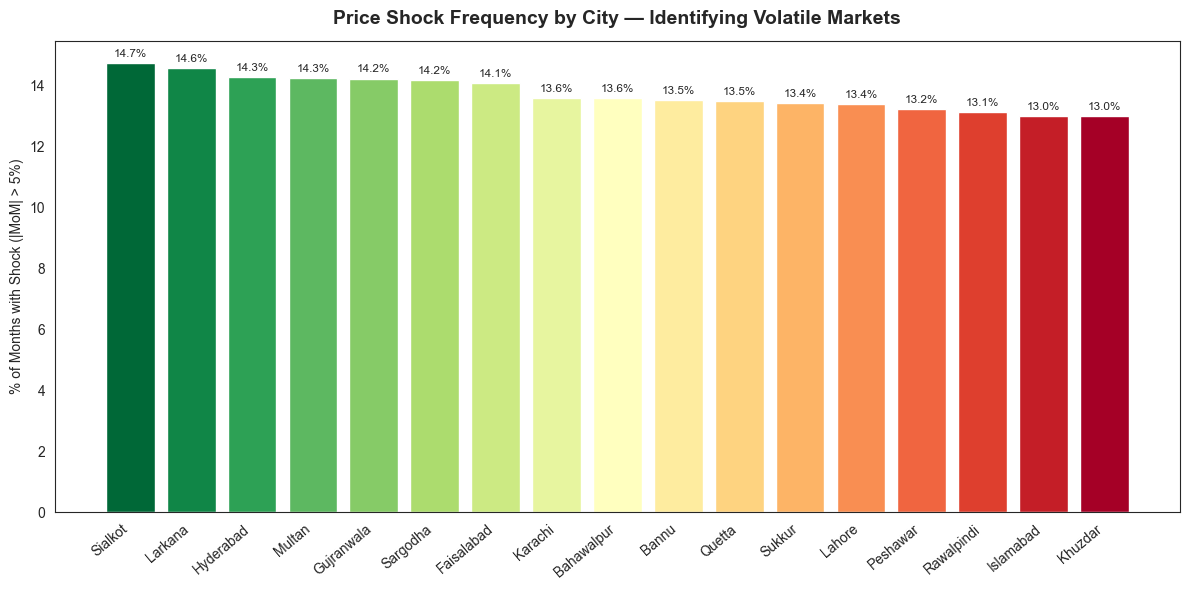

In [19]:
# ============================================================
# CELL 11 — ADF Unit Root Tests (stationarity per city)
# ============================================================

adf_results = []
for city in cities:
    ts = (df[df['City']==city]
            .groupby('Date')['Value'].median()
            .sort_index().dropna())
    if len(ts) < 12: continue
    stat, p, *_ = adfuller(ts, autolag='AIC')
    adf_results.append({'City':city, 'ADF_stat':stat, 'p_value':p,
                        'Stationary': '✅ Yes' if p < 0.05 else '❌ No'})

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in adf_df['p_value']]
ax.barh(adf_df['City'], adf_df['p_value'], color=colors)
ax.axvline(0.05, color='#333', ls='--', lw=1.2, label='p = 0.05 threshold')
ax.set_xlabel('ADF p-value'); ax.set_title('ADF Stationarity Test by City',
                                             fontsize=14, fontweight='bold', pad=12)
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 12 — Granger Causality — Islamabad → Other Cities
# (Does Islamabad price Granger-cause prices in other cities?)
# ============================================================

# Use Wheat Flour as the reference commodity
REF_COMMODITY = 'Wheat Flour Bag 20 Kg'

# Pivot to city-level monthly series
pivot = (df[df['Commodity'].str.contains('Wheat Flour', na=False)]
           .groupby(['Date','City'])['Value'].median()
           .unstack('City').sort_index().dropna(how='all'))
pivot = pivot.ffill().dropna()

granger_results = []
REF = 'Islamabad'
if REF in pivot.columns:
    for city in [c for c in pivot.columns if c != REF]:
        data = pivot[[REF, city]].dropna()
        if len(data) < 10: continue
        try:
            res = grangercausalitytests(data[[city, REF]], maxlag=3, verbose=False)
            min_p = min(res[lag][0]['ssr_ftest'][1] for lag in [1,2,3])
            granger_results.append({'City':city, 'Min_p':min_p,
                                    'Granger_caused':'✅ Yes' if min_p < 0.05 else '❌ No'})
        except Exception:
            pass

g_df = pd.DataFrame(granger_results).sort_values('Min_p')
print(f'Granger Causality: Islamabad → Other Cities (Wheat Flour)')
print(g_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#27ae60' if p < 0.05 else '#e74c3c' for p in g_df['Min_p']]
ax.barh(g_df['City'], g_df['Min_p'], color=bar_colors)
ax.axvline(0.05, color='#333', ls='--', lw=1.3, label='Significance threshold (0.05)')
ax.set_xlabel('Minimum Granger p-value (lags 1–3)')
ax.set_title('Does Islamabad Price Granger-Cause Prices in Other Cities?\n(Wheat Flour Bag 20 Kg)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 13 — Cross-City Correlation Heatmap (Supply Chain Integration)
# ============================================================

# National average price per city per date
city_ts = df.groupby(['City','Date'])['Value'].median().unstack('City').sort_index()
city_ts = city_ts.ffill().dropna()

corr = city_ts.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.4, ax=ax,
            cbar_kws={'label':'Pearson Correlation'})
ax.set_title('Inter-City Price Correlation Matrix — Market Integration Index',
             fontsize=14, fontweight='bold', pad=14)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 14 — Shock Frequency by City (Price-Leading Hubs)
# ============================================================

shock_rate = (df.groupby('City')['Shock'].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
palette_shock = plt.colormaps['RdYlGn_r'].resampled(len(shock_rate))
bars = ax.bar(shock_rate.index, shock_rate.values,
              color=[palette_shock(i) for i in np.linspace(0, 1, len(shock_rate))])
ax.set_xticklabels(shock_rate.index, rotation=40, ha='right')
ax.set_ylabel('% of Months with Shock (|MoM| > 5%)')
ax.set_title('Price Shock Frequency by City — Identifying Volatile Markets',
             fontsize=14, fontweight='bold', pad=12)
for bar, val in zip(bars, shock_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', fontsize=8.5)
fig.tight_layout(); plt.show()

## **5. PCA — Dimensionality Reduction**

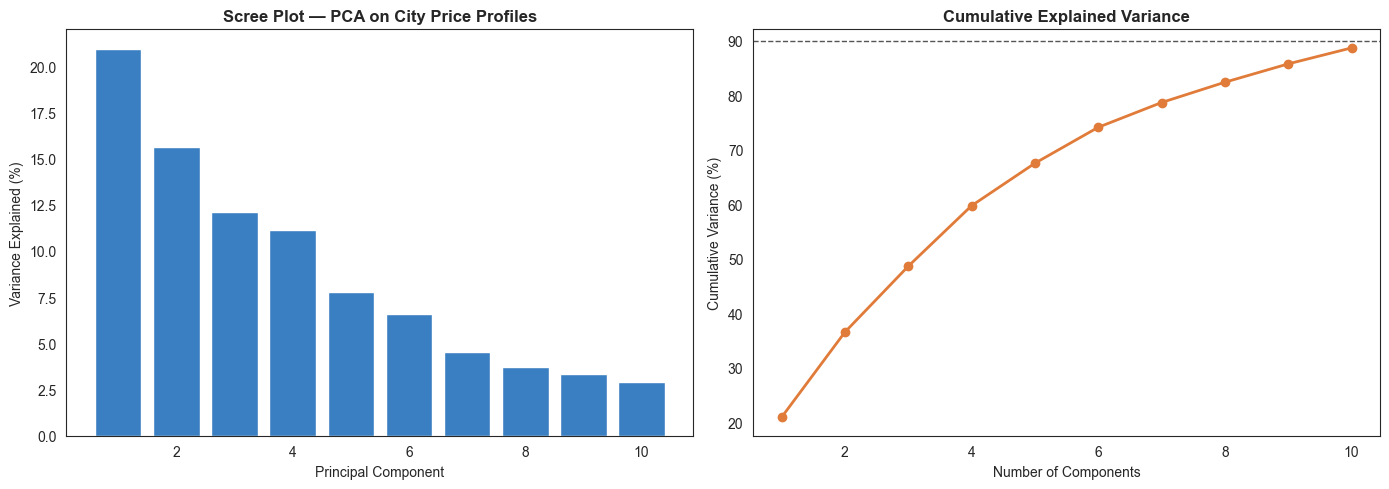

PC1 + PC2 explain 36.6% of variance


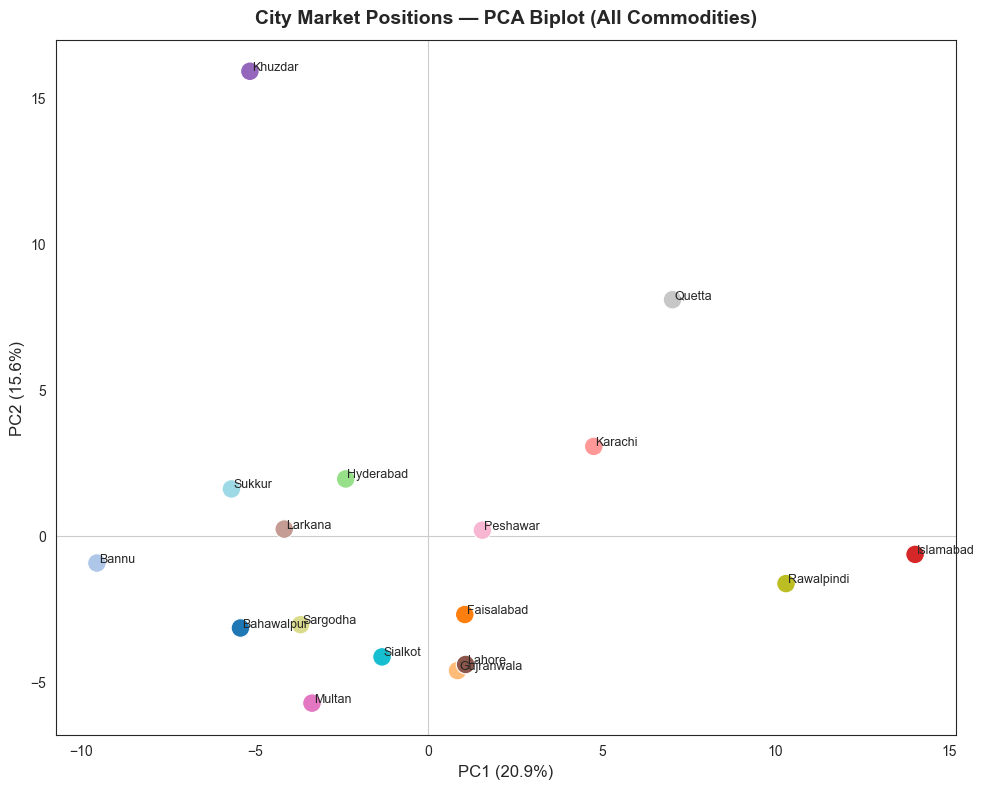

In [20]:
# ============================================================
# CELL 15 — Build City-Feature Matrix & Run PCA
# ============================================================

# Feature matrix: each row = city, columns = commodity monthly avg prices
city_comm = (df.groupby(['City','Commodity'])['Value'].median()
               .unstack('Commodity').ffill().fillna(0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_comm)

pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_ * 100,
            color='#3a7fc1', edgecolor='white')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — PCA on City Price Profiles', fontweight='bold')

axes[1].plot(range(1, len(pca.explained_variance_ratio_)+1),
             np.cumsum(pca.explained_variance_ratio_)*100,
             marker='o', color='#e07b39', lw=2)
axes[1].axhline(90, color='#555', ls='--', lw=1)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
fig.tight_layout(); plt.show()

print(f'PC1 + PC2 explain {sum(pca.explained_variance_ratio_[:2])*100:.1f}% of variance')
# ============================================================
# CELL 16 — PCA Biplot: City Positions in PC Space
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     s=180, c=np.arange(len(city_comm)),
                     cmap='tab20', zorder=3, edgecolors='white', lw=0.8)
for i, city in enumerate(city_comm.index):
    ax.annotate(city, (X_pca[i, 0]+0.05, X_pca[i, 1]+0.05), fontsize=9)

ax.axhline(0, color='#ccc', lw=0.8); ax.axvline(0, color='#ccc', lw=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('City Market Positions — PCA Biplot (All Commodities)',
             fontsize=14, fontweight='bold', pad=12)
fig.tight_layout(); plt.show()

## **6. Clustering — Market Segmentation**

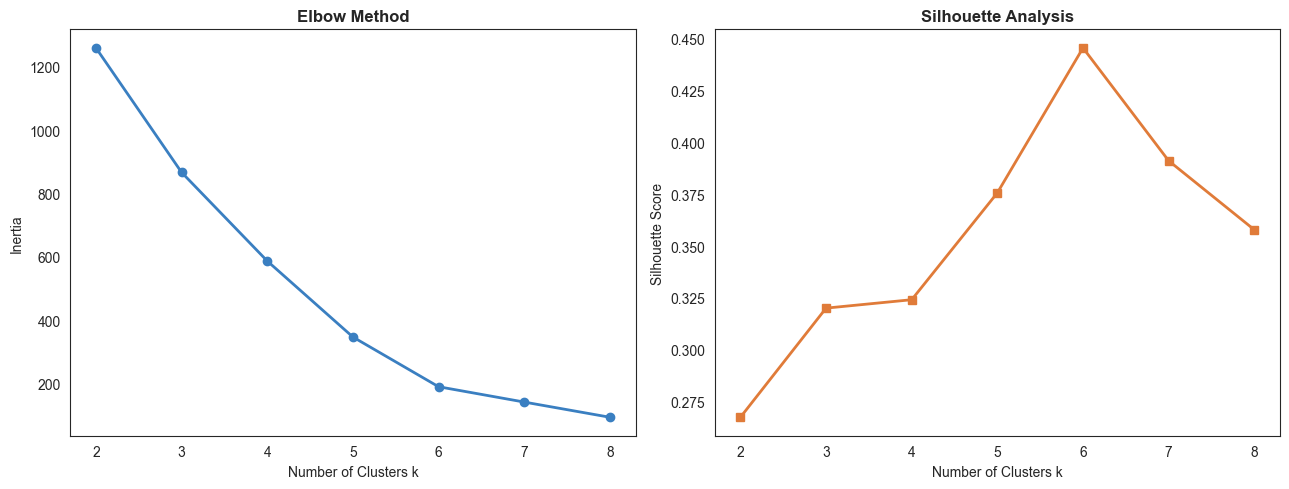

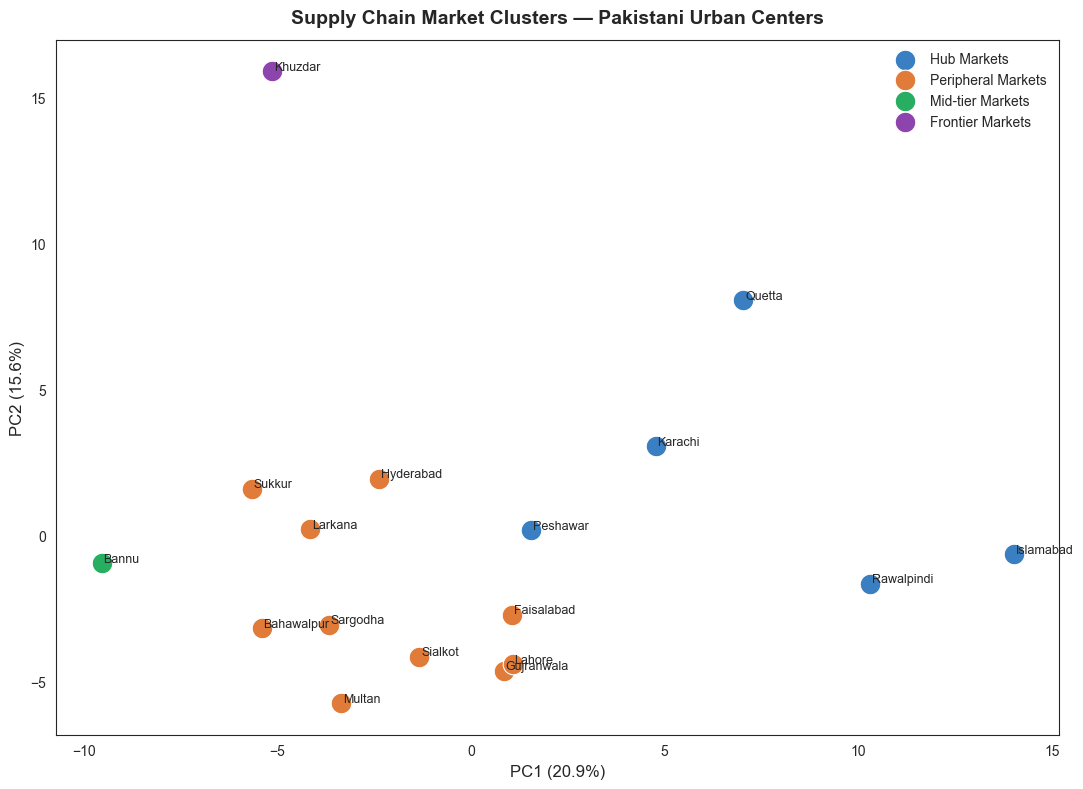


Cluster Assignments:
Commodity   Cluster         ClusterName
City                                   
Bahawalpur        1  Peripheral Markets
Bannu             2    Mid-tier Markets
Faisalabad        1  Peripheral Markets
Gujranwala        1  Peripheral Markets
Hyderabad         1  Peripheral Markets
Islamabad         0         Hub Markets
Karachi           0         Hub Markets
Khuzdar           3    Frontier Markets
Lahore            1  Peripheral Markets
Larkana           1  Peripheral Markets
Multan            1  Peripheral Markets
Peshawar          0         Hub Markets
Quetta            0         Hub Markets
Rawalpindi        0         Hub Markets
Sargodha          1  Peripheral Markets
Sialkot           1  Peripheral Markets
Sukkur            1  Peripheral Markets


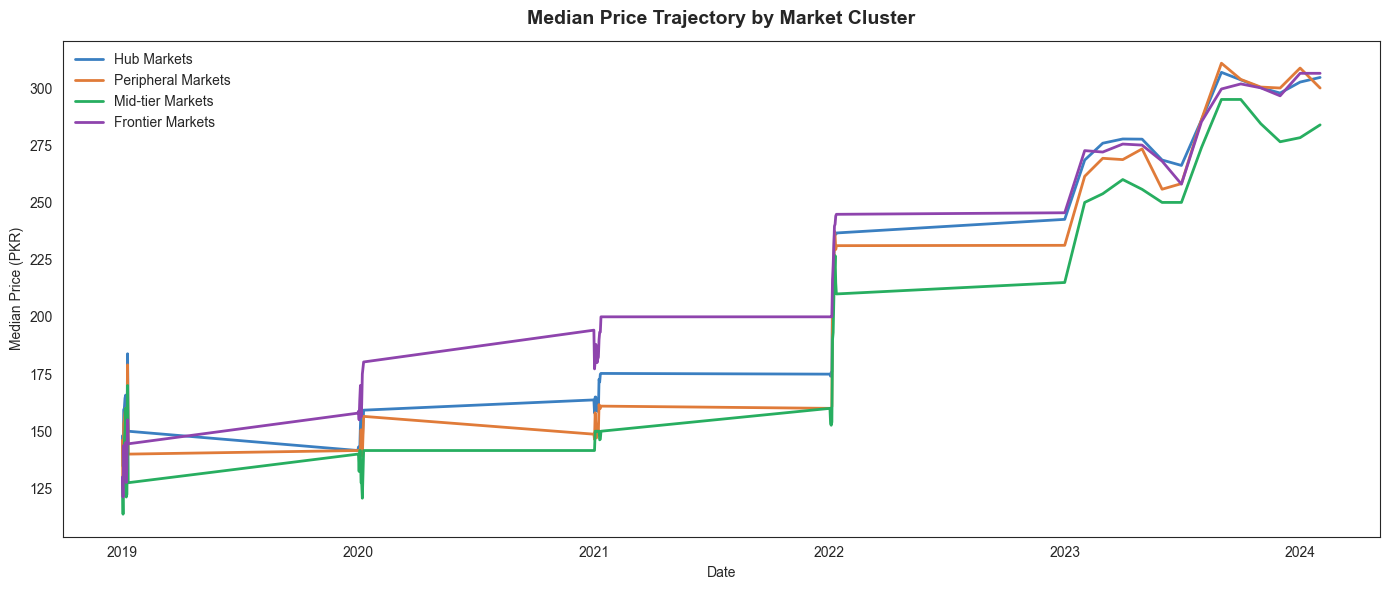

In [21]:
# ============================================================
# CELL 17 — KMeans Elbow Method
# ============================================================

inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca[:, :4])  # use top 4 PCs
    inertias.append(km.inertia_)
    if k < len(X_pca):  # silhouette needs at least 2 samples per cluster
        sil_scores.append(silhouette_score(X_pca[:, :4], labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker='o', color='#3a7fc1', lw=2)
axes[0].set_xlabel('Number of Clusters k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(list(K_range)[:len(sil_scores)], sil_scores, marker='s', color='#e07b39', lw=2)
axes[1].set_xlabel('Number of Clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontweight='bold')
fig.tight_layout(); plt.show()
# ============================================================
# CELL 18 — Final KMeans Clustering (k=4) + Cluster Map
# ============================================================

OPTIMAL_K = 4
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca[:, :4])
city_comm['Cluster'] = cluster_labels

CLUSTER_NAMES = {
    0: 'Hub Markets',
    1: 'Peripheral Markets',
    2: 'Mid-tier Markets',
    3: 'Frontier Markets',
}
city_comm['ClusterName'] = city_comm['Cluster'].map(CLUSTER_NAMES)

cpal = ['#3a7fc1','#e07b39','#27ae60','#8e44ad']
fig, ax = plt.subplots(figsize=(11, 8))
for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=220, color=cpal[k], label=CLUSTER_NAMES[k],
               zorder=3, edgecolors='white', lw=0.8)
    for idx in np.where(mask)[0]:
        ax.annotate(city_comm.index[idx], (X_pca[idx,0]+0.05, X_pca[idx,1]+0.05), fontsize=9)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Supply Chain Market Clusters — Pakistani Urban Centers',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=10)
fig.tight_layout(); plt.show()

print('\nCluster Assignments:')
print(city_comm[['Cluster','ClusterName']].to_string())
# ============================================================
# CELL 19 — Cluster Price Profile Comparison
# ============================================================

cluster_city_map = city_comm[['Cluster']].reset_index()
df_clust = df.merge(cluster_city_map, on='City', how='left')

cluster_ts = df_clust.groupby(['Cluster','Date'])['Value'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for k in range(OPTIMAL_K):
    sub = cluster_ts[cluster_ts['Cluster'] == k]
    ax.plot(sub['Date'], sub['Value'], lw=2, color=cpal[k], label=CLUSTER_NAMES[k])

ax.set_title('Median Price Trajectory by Market Cluster', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Median Price (PKR)')
ax.legend(frameon=False, fontsize=10)
fig.tight_layout(); plt.show()

## **7. ML Regressors — Price Forecasting**

Train : 72,512  Test : 18,129
  Ridge Regression                MAE=    8.44  RMSE=   24.69  R²=0.9979
  Random Forest                   MAE=    1.07  RMSE=    7.68  R²=0.9998
  Gradient Boosting               MAE=    5.96  RMSE=   13.13  R²=0.9994
  XGBoost                         MAE=    3.65  RMSE=   10.99  R²=0.9996

  Best model: Random Forest (R²=0.9998)


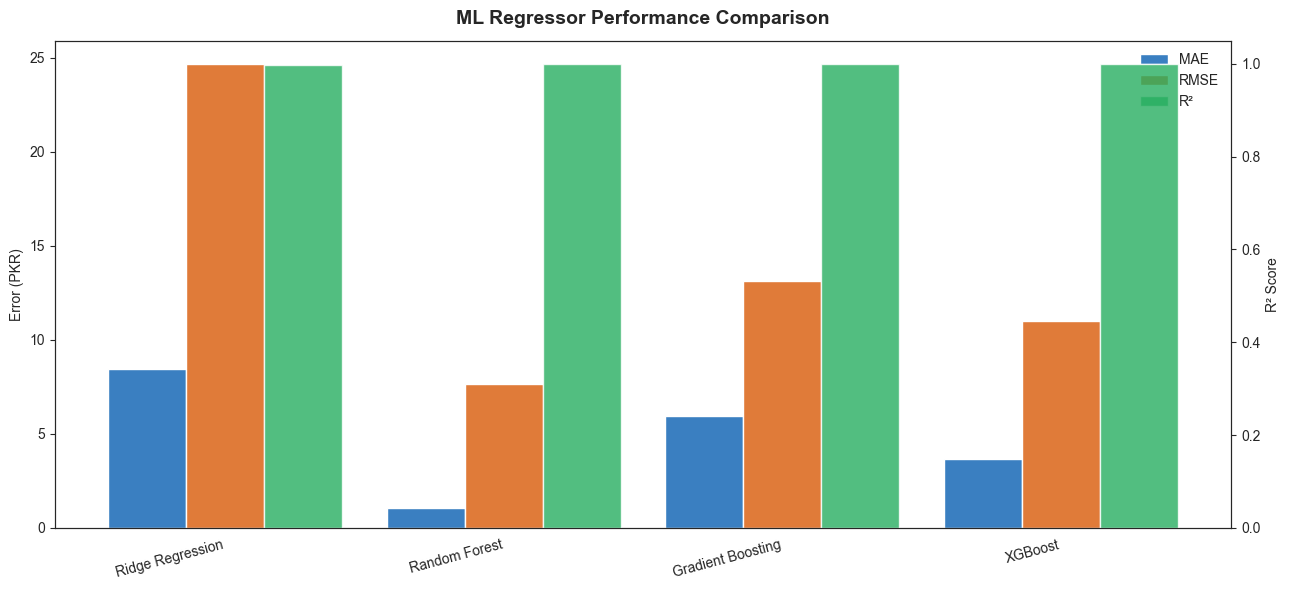

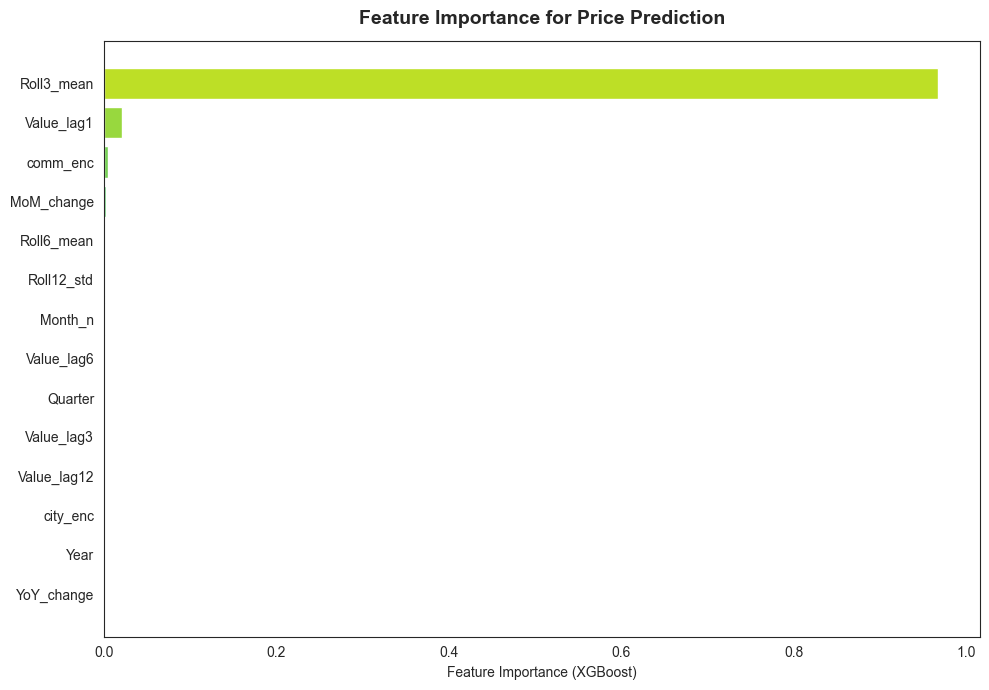

In [22]:
# ============================================================
# CELL 20 — Prepare ML Feature Matrix
# ============================================================

le_city = LabelEncoder()
le_comm = LabelEncoder()

ml_df = df.dropna(subset=['Value_lag1','Value_lag3','Roll6_mean','MoM_change']).copy()
ml_df['city_enc'] = le_city.fit_transform(ml_df['City'])
ml_df['comm_enc'] = le_comm.fit_transform(ml_df['Commodity'])

FEATURES = ['city_enc','comm_enc','Year','Quarter','Month_n',
            'Value_lag1','Value_lag3','Value_lag6','Value_lag12',
            'Roll3_mean','Roll6_mean','Roll12_std','MoM_change','YoY_change']

X = ml_df[FEATURES].fillna(0).values
y = ml_df['Value'].values

# Chronological split (80 / 20)
split = int(len(X) * 0.8)
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]
print(f'Train : {X_tr.shape[0]:,}  Test : {X_te.shape[0]:,}')
# ============================================================
# CELL 21 — Train Multiple Regressors & Compare
# ============================================================

regressors = {
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Random Forest'           : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                 : xgb.XGBRegressor(n_estimators=100, random_state=42,
                                                  verbosity=0, n_jobs=-1),
}

reg_results = {}
for name, model in regressors.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    reg_results[name] = {'MAE':mae,'RMSE':rmse,'R2':r2,'preds':preds}
    print(f'  {name:30s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  R²={r2:.4f}')

# Best model for later use
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2'])
best_reg_model = regressors[best_reg_name]
print(f'\n  Best model: {best_reg_name} (R²={reg_results[best_reg_name]["R2"]:.4f})')
# ============================================================
# CELL 22 — Regressor Performance Comparison Chart
# ============================================================

names_r  = list(reg_results.keys())
mae_vals  = [reg_results[n]['MAE']  for n in names_r]
rmse_vals = [reg_results[n]['RMSE'] for n in names_r]
r2_vals   = [reg_results[n]['R2']   for n in names_r]

x_ = np.arange(len(names_r)); w = 0.28
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x_-w,  mae_vals,  width=w, label='MAE',  color='#3a7fc1')
ax.bar(x_,    rmse_vals, width=w, label='RMSE', color='#e07b39')
ax2 = ax.twinx()
ax2.bar(x_+w, r2_vals,  width=w, label='R²',   color='#27ae60', alpha=0.8)
ax.set_xticks(x_); ax.set_xticklabels(names_r, rotation=15, ha='right')
ax.set_ylabel('Error (PKR)'); ax2.set_ylabel('R² Score')
ax.set_title('ML Regressor Performance Comparison', fontsize=14, fontweight='bold', pad=12)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, frameon=False)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 23 — Feature Importance (XGBoost)
# ============================================================

xgb_model = regressors['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = cm.viridis(np.linspace(0.2, 0.9, len(importances)))
ax.barh(importances.index, importances.values, color=colors_fi)
ax.set_xlabel('Feature Importance (XGBoost)')
ax.set_title('Feature Importance for Price Prediction', fontsize=14, fontweight='bold', pad=12)
fig.tight_layout(); plt.show()

## **8. ML Classifiers — Shock Direction Prediction**

  Logistic Regression        Accuracy: 0.9988
  Random Forest              Accuracy: 1.0000
  Gradient Boosting          Accuracy: 1.0000
  XGBoost                    Accuracy: 0.9985

  Best classifier: Random Forest


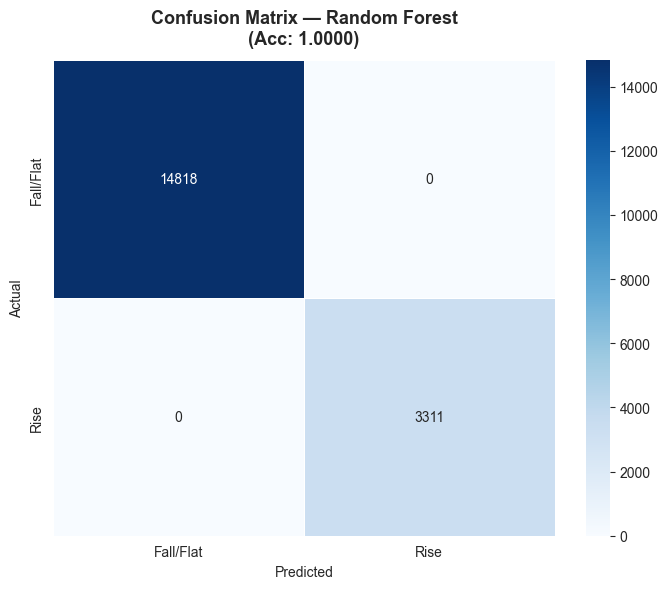

In [23]:
# ============================================================
# CELL 24 — Classify Whether Next Month Price Will Rise / Fall
# ============================================================

clf_df = ml_df.dropna(subset=['ShockDirection']).copy()
clf_df['Target'] = (clf_df['ShockDirection'] > 0).astype(int)  # 1=rise, 0=fall/flat

X_c = clf_df[FEATURES].fillna(0).values
y_c = clf_df['Target'].values

split_c = int(len(X_c) * 0.8)
Xc_tr, Xc_te = X_c[:split_c], X_c[split_c:]
yc_tr, yc_te = y_c[:split_c], y_c[split_c:]

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                               verbosity=0, eval_metric='logloss'),
}

clf_results = {}
for name, clf in classifiers.items():
    clf.fit(Xc_tr, yc_tr)
    preds = clf.predict(Xc_te)
    report = classification_report(yc_te, preds, output_dict=True)
    acc = report['accuracy']
    clf_results[name] = {'accuracy':acc,'report':report,'preds':preds}
    print(f'  {name:25s}  Accuracy: {acc:.4f}')
    
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['accuracy'])
print(f'\n  Best classifier: {best_clf_name}')
# ============================================================
# CELL 25 — Confusion Matrix for Best Classifier
# ============================================================

best_clf  = classifiers[best_clf_name]
best_preds_c = clf_results[best_clf_name]['preds']
cm_mat = confusion_matrix(yc_te, best_preds_c)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Fall/Flat','Rise'], yticklabels=['Fall/Flat','Rise'],
            linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_clf_name}\n(Acc: {clf_results[best_clf_name]["accuracy"]:.4f})',
             fontsize=13, fontweight='bold', pad=12)
fig.tight_layout(); plt.show()

## **9. Deep Learning — PyTorch LSTM**

Using device: cpu
LSTM sequences — Train: torch.Size([35, 12, 1])  Test: torch.Size([9, 12, 1])
  Epoch  10/60  TrainLoss=0.37906  ValLoss=2.38671
  Epoch  20/60  TrainLoss=0.03753  ValLoss=0.08108
  Epoch  30/60  TrainLoss=0.04707  ValLoss=0.21068
  Epoch  40/60  TrainLoss=0.04208  ValLoss=0.07733
  Epoch  50/60  TrainLoss=0.05924  ValLoss=0.09430
  Epoch  60/60  TrainLoss=0.03086  ValLoss=0.10174
LSTM training complete.


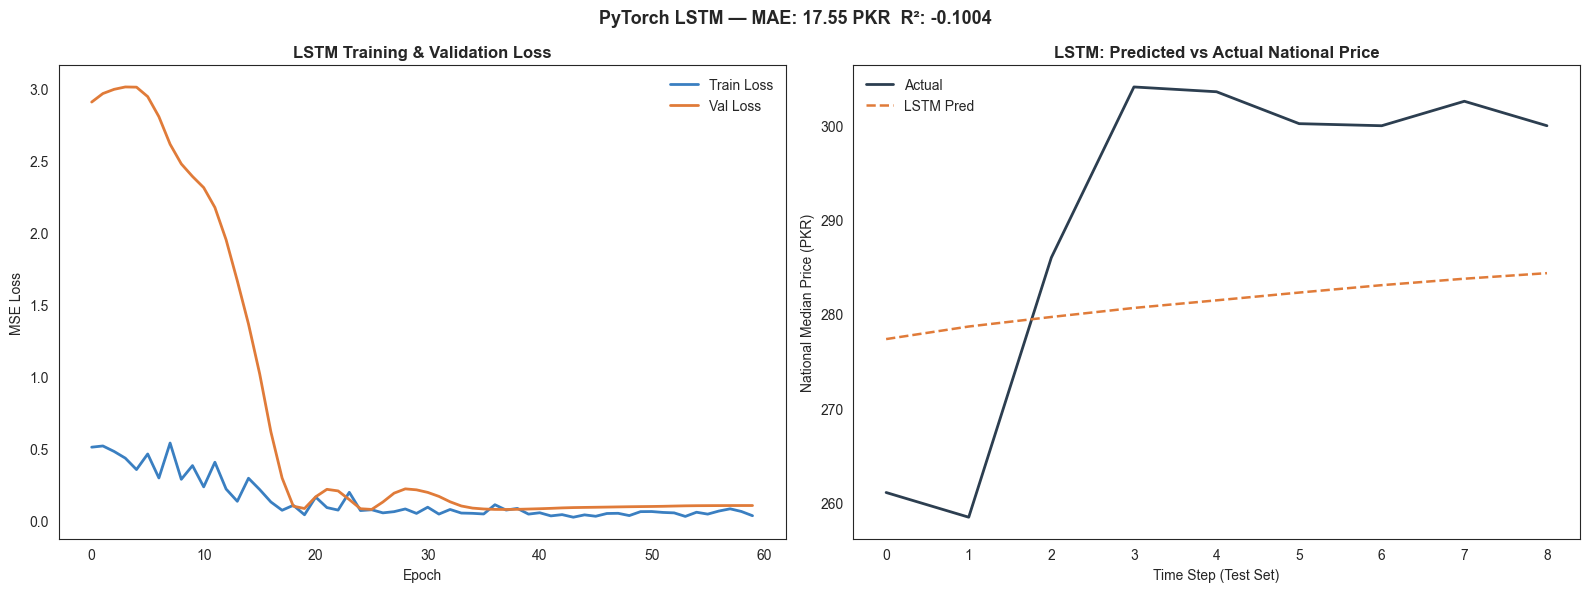

In [24]:
# ============================================================
# CELL 26 — LSTM Architecture Definition (PyTorch)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class PriceTransmissionLSTM(nn.Module):
    """Stacked LSTM with dropout for multi-step price prediction."""
    def __init__(self, input_size=1, hidden_size=128, num_layers=2,
                 dropout=0.2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        return self.fc(out[:, -1, :])  # use last timestep
# ============================================================
# CELL 27 — Prepare Sequences for LSTM (National Average Price)
# ============================================================

SEQ_LEN   = 12   # 12-month look-back window
BATCH     = 32
EPOCHS    = 60
LR        = 1e-3
HIDDEN    = 128
N_LAYERS  = 2

# Use national median price series
nat_series = (df.groupby('Date')['Value'].median()
                .sort_index().values.astype(np.float32))

sc_lstm = StandardScaler()
nat_scaled = sc_lstm.fit_transform(nat_series.reshape(-1,1)).flatten()

def make_sequences(series, seq_len):
    Xs, ys = [], []
    for i in range(len(series) - seq_len):
        Xs.append(series[i:i+seq_len])
        ys.append(series[i+seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_seq = make_sequences(nat_scaled, SEQ_LEN)

split_lstm = int(len(X_seq) * 0.8)
Xl_tr = torch.tensor(X_seq[:split_lstm, :, np.newaxis])   # (N, T, 1)
yl_tr = torch.tensor(y_seq[:split_lstm, np.newaxis])
Xl_te = torch.tensor(X_seq[split_lstm:, :, np.newaxis])
yl_te = torch.tensor(y_seq[split_lstm:, np.newaxis])

train_ds = TensorDataset(Xl_tr, yl_tr)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)

print(f'LSTM sequences — Train: {Xl_tr.shape}  Test: {Xl_te.shape}')
# ============================================================
# CELL 28 — Train LSTM
# ============================================================

lstm_model = PriceTransmissionLSTM(
    input_size=1, hidden_size=HIDDEN, num_layers=N_LAYERS, dropout=0.2
).to(device)

criterion  = nn.MSELoss()
optimizer  = optim.Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses = [], []
lstm_model.train()

for epoch in range(1, EPOCHS+1):
    epoch_loss = 0.0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    
    # Validation
    lstm_model.eval()
    with torch.no_grad():
        val_pred = lstm_model(Xl_te.to(device))
        val_loss = criterion(val_pred, yl_te.to(device)).item()
    lstm_model.train()
    
    train_losses.append(epoch_loss / len(train_dl))
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS}  TrainLoss={train_losses[-1]:.5f}  ValLoss={val_loss:.5f}')

print('LSTM training complete.')
# ============================================================
# CELL 29 — LSTM Training Curves & Prediction vs Actual
# ============================================================

lstm_model.eval()
with torch.no_grad():
    lstm_preds_scaled = lstm_model(Xl_te.to(device)).cpu().numpy().flatten()
lstm_preds = sc_lstm.inverse_transform(lstm_preds_scaled.reshape(-1,1)).flatten()
lstm_actual = sc_lstm.inverse_transform(yl_te.numpy()).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='#3a7fc1', lw=2)
axes[0].plot(val_losses,   label='Val Loss',   color='#e07b39', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('LSTM Training & Validation Loss', fontweight='bold')
axes[0].legend(frameon=False)

# Prediction vs actual
axes[1].plot(lstm_actual, label='Actual',    color='#2c3e50', lw=2)
axes[1].plot(lstm_preds,  label='LSTM Pred', color='#e07b39', lw=1.8, ls='--')
axes[1].set_xlabel('Time Step (Test Set)')
axes[1].set_ylabel('National Median Price (PKR)')
axes[1].set_title('LSTM: Predicted vs Actual National Price', fontweight='bold')
axes[1].legend(frameon=False)

fig.suptitle(f'PyTorch LSTM — MAE: {mean_absolute_error(lstm_actual, lstm_preds):.2f} PKR  '
             f'R²: {r2_score(lstm_actual, lstm_preds):.4f}',
             fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()

## **10. NLP — Commodity Semantic Grouping**

Total unique commodities: 190


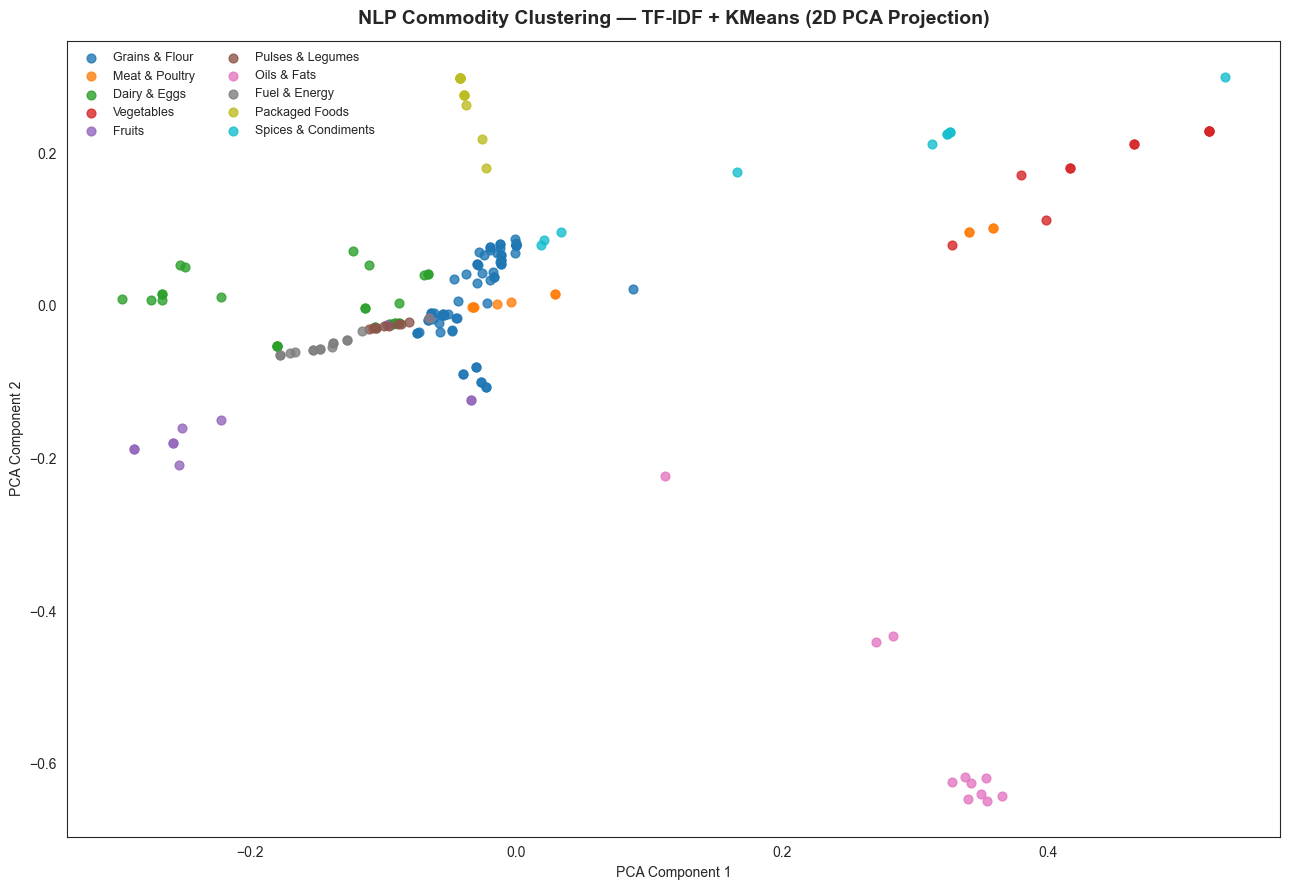

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

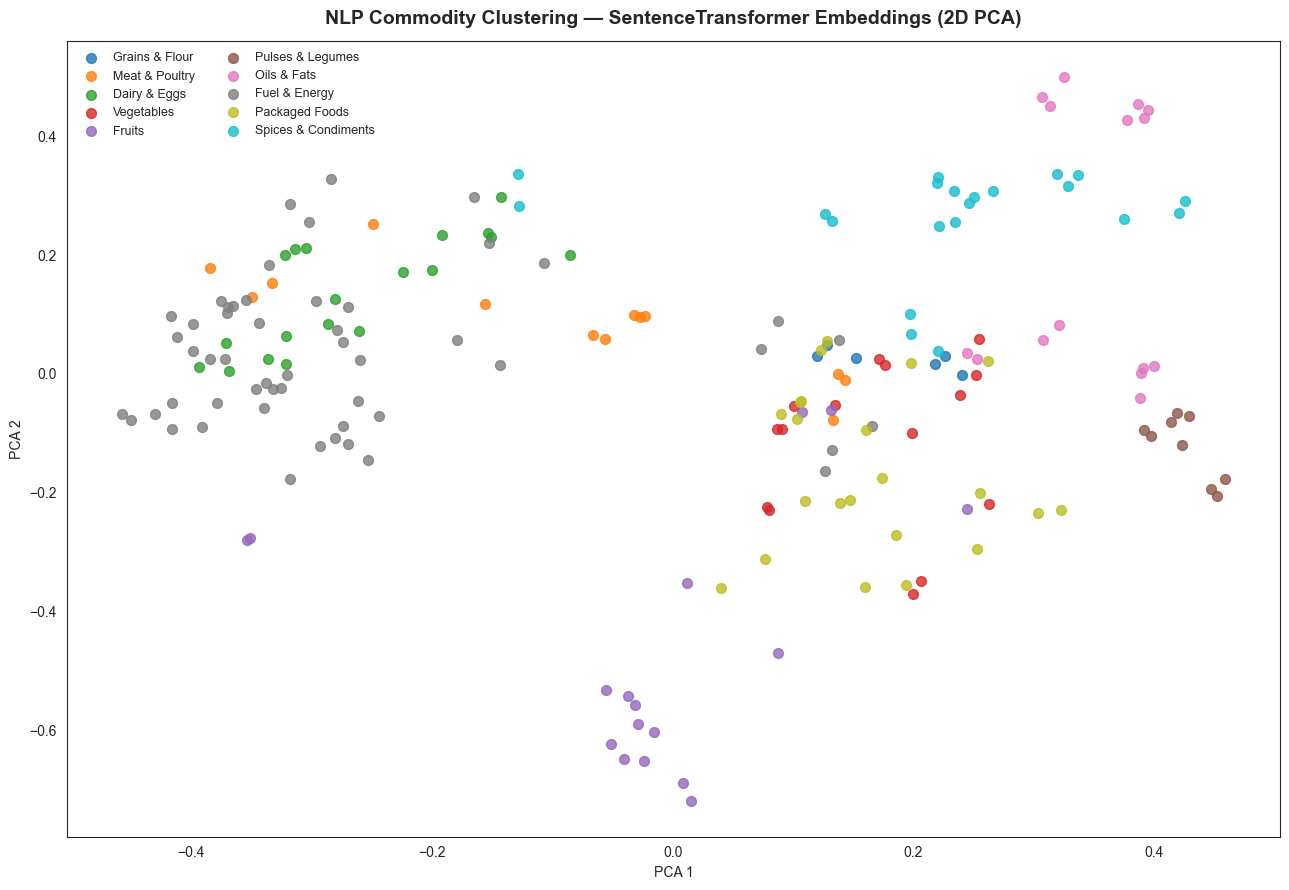

SentenceTransformer embeddings applied.


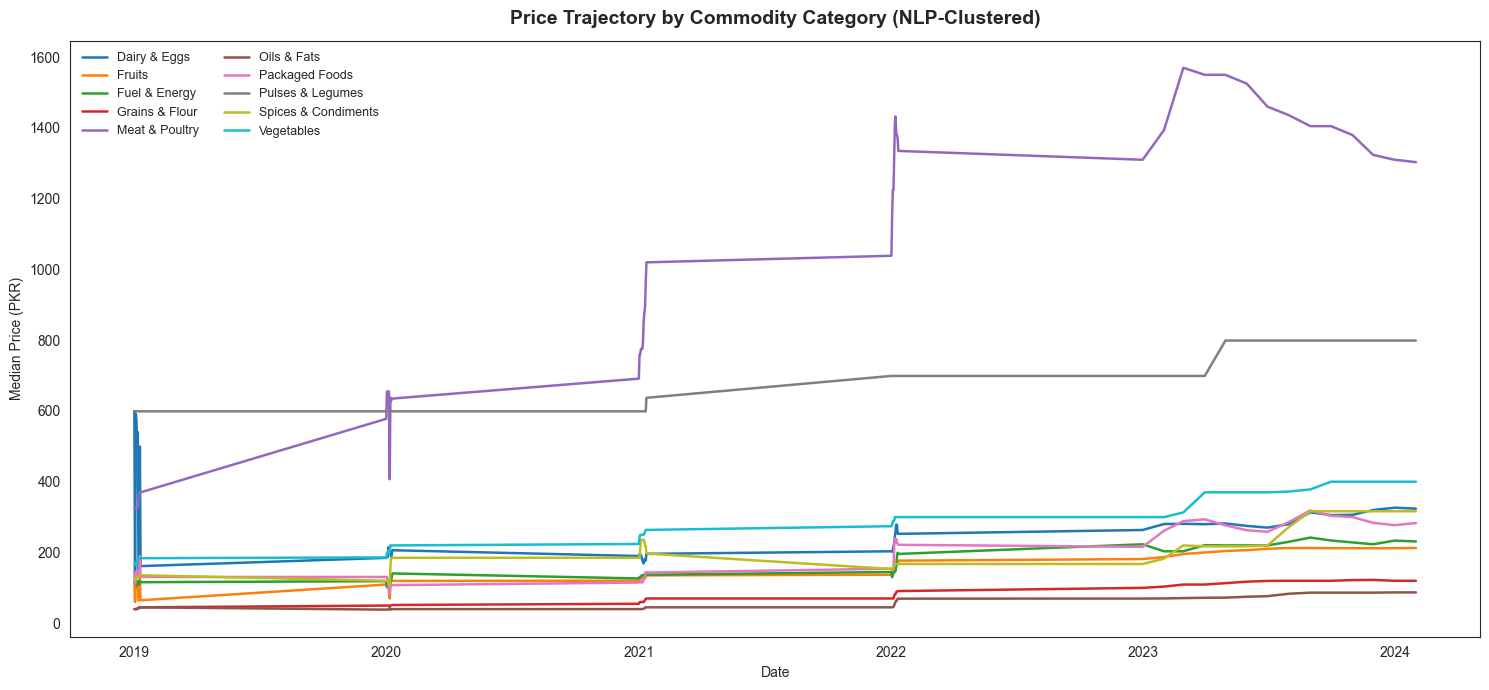

In [25]:
# ============================================================
# CELL 30 — TF-IDF Based Commodity Clustering
# ============================================================

commodities_list = df['Commodity'].unique().tolist()
print(f'Total unique commodities: {len(commodities_list)}')

# TF-IDF on commodity names
tfidf = TfidfVectorizer(ngram_range=(1,2), analyzer='word',
                        token_pattern=r'[a-zA-Z]+', min_df=1)
comm_tfidf = tfidf.fit_transform(commodities_list).toarray()

# PCA for visualisation
pca_comm = PCA(n_components=2, random_state=42)
comm_2d = pca_comm.fit_transform(comm_tfidf)

# KMeans into food groups
N_GROUPS = 10
km_comm = KMeans(n_clusters=N_GROUPS, random_state=42, n_init=10)
comm_clusters = km_comm.fit_predict(comm_tfidf)

GROUP_NAMES = [
    'Grains & Flour','Meat & Poultry','Dairy & Eggs','Vegetables',
    'Fruits','Pulses & Legumes','Oils & Fats','Fuel & Energy',
    'Packaged Foods','Spices & Condiments'
]

fig, ax = plt.subplots(figsize=(13, 9))
cmap_comm = plt.colormaps['tab10'].resampled(N_GROUPS)
for g in range(N_GROUPS):
    mask_g = comm_clusters == g
    ax.scatter(comm_2d[mask_g, 0], comm_2d[mask_g, 1],
               s=40, color=cmap_comm(g), label=GROUP_NAMES[g], alpha=0.8)

ax.set_title('NLP Commodity Clustering — TF-IDF + KMeans (2D PCA Projection)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('PCA Component 1'); ax.set_ylabel('PCA Component 2')
ax.legend(ncol=2, frameon=False, fontsize=9)
fig.tight_layout(); plt.show()
# ============================================================
# CELL 31 — Semantic Embeddings via SentenceTransformer
# (Optional — requires: pip install sentence-transformers)
# ============================================================

try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = st_model.encode(commodities_list, show_progress_bar=False)
    
    pca_emb = PCA(n_components=2, random_state=42)
    emb_2d  = pca_emb.fit_transform(embeddings)
    km_emb  = KMeans(n_clusters=N_GROUPS, random_state=42, n_init=10)
    emb_clusters = km_emb.fit_predict(embeddings)
    
    fig, ax = plt.subplots(figsize=(13, 9))
    for g in range(N_GROUPS):
        mask_g = emb_clusters == g
        ax.scatter(emb_2d[mask_g, 0], emb_2d[mask_g, 1],
                   s=50, color=cmap_comm(g), label=GROUP_NAMES[g], alpha=0.8)
    ax.set_title('NLP Commodity Clustering — SentenceTransformer Embeddings (2D PCA)',
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(ncol=2, frameon=False, fontsize=9)
    fig.tight_layout(); plt.show()
    
    # Assign group label back to df
    comm_group_map = dict(zip(commodities_list, [GROUP_NAMES[c] for c in emb_clusters]))
    df['CommodityGroup'] = df['Commodity'].map(comm_group_map)
    print('SentenceTransformer embeddings applied.')

except ImportError:
    print('SentenceTransformer not installed — using TF-IDF groups instead.')
    comm_group_map = dict(zip(commodities_list, [GROUP_NAMES[c] for c in comm_clusters]))
    df['CommodityGroup'] = df['Commodity'].map(comm_group_map)
# ============================================================
# CELL 32 — Inflation by Commodity Group Over Time
# ============================================================

grp_ts = df.groupby(['CommodityGroup','Date'])['Value'].median().reset_index()
groups = grp_ts['CommodityGroup'].unique()
cmap_g = plt.colormaps['tab10'].resampled(len(groups))

fig, ax = plt.subplots(figsize=(15, 7))
for i, g in enumerate(groups):
    sub = grp_ts[grp_ts['CommodityGroup'] == g]
    ax.plot(sub['Date'], sub['Value'], lw=1.8, label=g, color=cmap_g(i))

ax.set_title('Price Trajectory by Commodity Category (NLP-Clustered)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Median Price (PKR)')
ax.legend(ncol=2, frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

## **11. Time Series Analysis — SARIMA & Seasonal Decomposition**

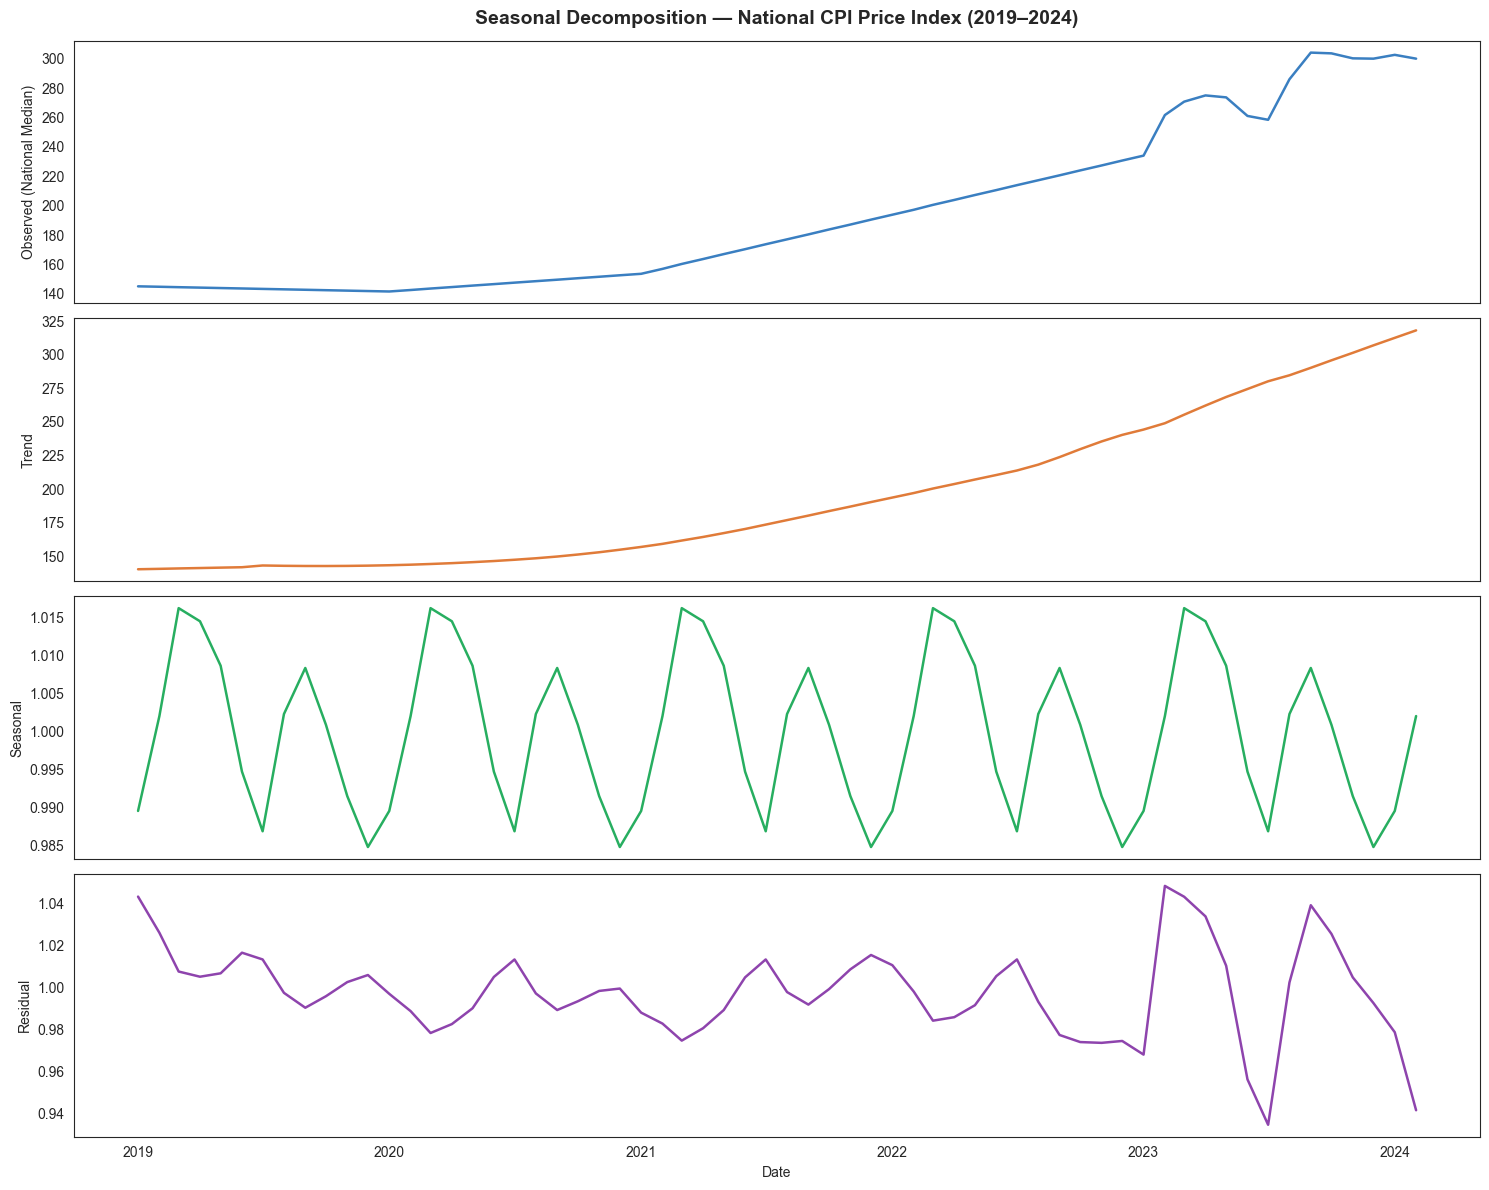

In [27]:
# ============================================================
# CELL 33 — Seasonal Decomposition (National Price Index)
# ============================================================

nat_ts = df.groupby('Date')['Value'].median().sort_index()
nat_ts.index = pd.DatetimeIndex(nat_ts.index)
nat_ts = nat_ts.asfreq('MS')  # monthly start frequency

# FIX: Missing values (NaNs) ko linearly fill karne ke liye takay decomposition error na de
nat_ts = nat_ts.interpolate(method='linear')

# Agar shuruat ya aakhir mein ab bhi koi NaN bacha ho toh ffill aur bfill safely handle kar lenge
nat_ts = nat_ts.ffill().bfill()

decomp = seasonal_decompose(nat_ts, model='multiplicative', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
components = {
    'Observed (National Median)': decomp.observed,
    'Trend':    decomp.trend,
    'Seasonal': decomp.seasonal,
    'Residual': decomp.resid,
}
colors_d = ['#3a7fc1','#e07b39','#27ae60','#8e44ad']
for ax, (title, series), color in zip(axes, components.items(), colors_d):
    ax.plot(series.index, series.values, color=color, lw=1.8)
    ax.set_ylabel(title, fontsize=10)
    ax.set_facecolor('white')
axes[0].set_title('Seasonal Decomposition — National CPI Price Index (2019–2024)',
                  fontsize=14, fontweight='bold', pad=12)
axes[-1].set_xlabel('Date')
fig.tight_layout(); plt.show()

## **12. 20-Year Price Forecast (2025–2044)**

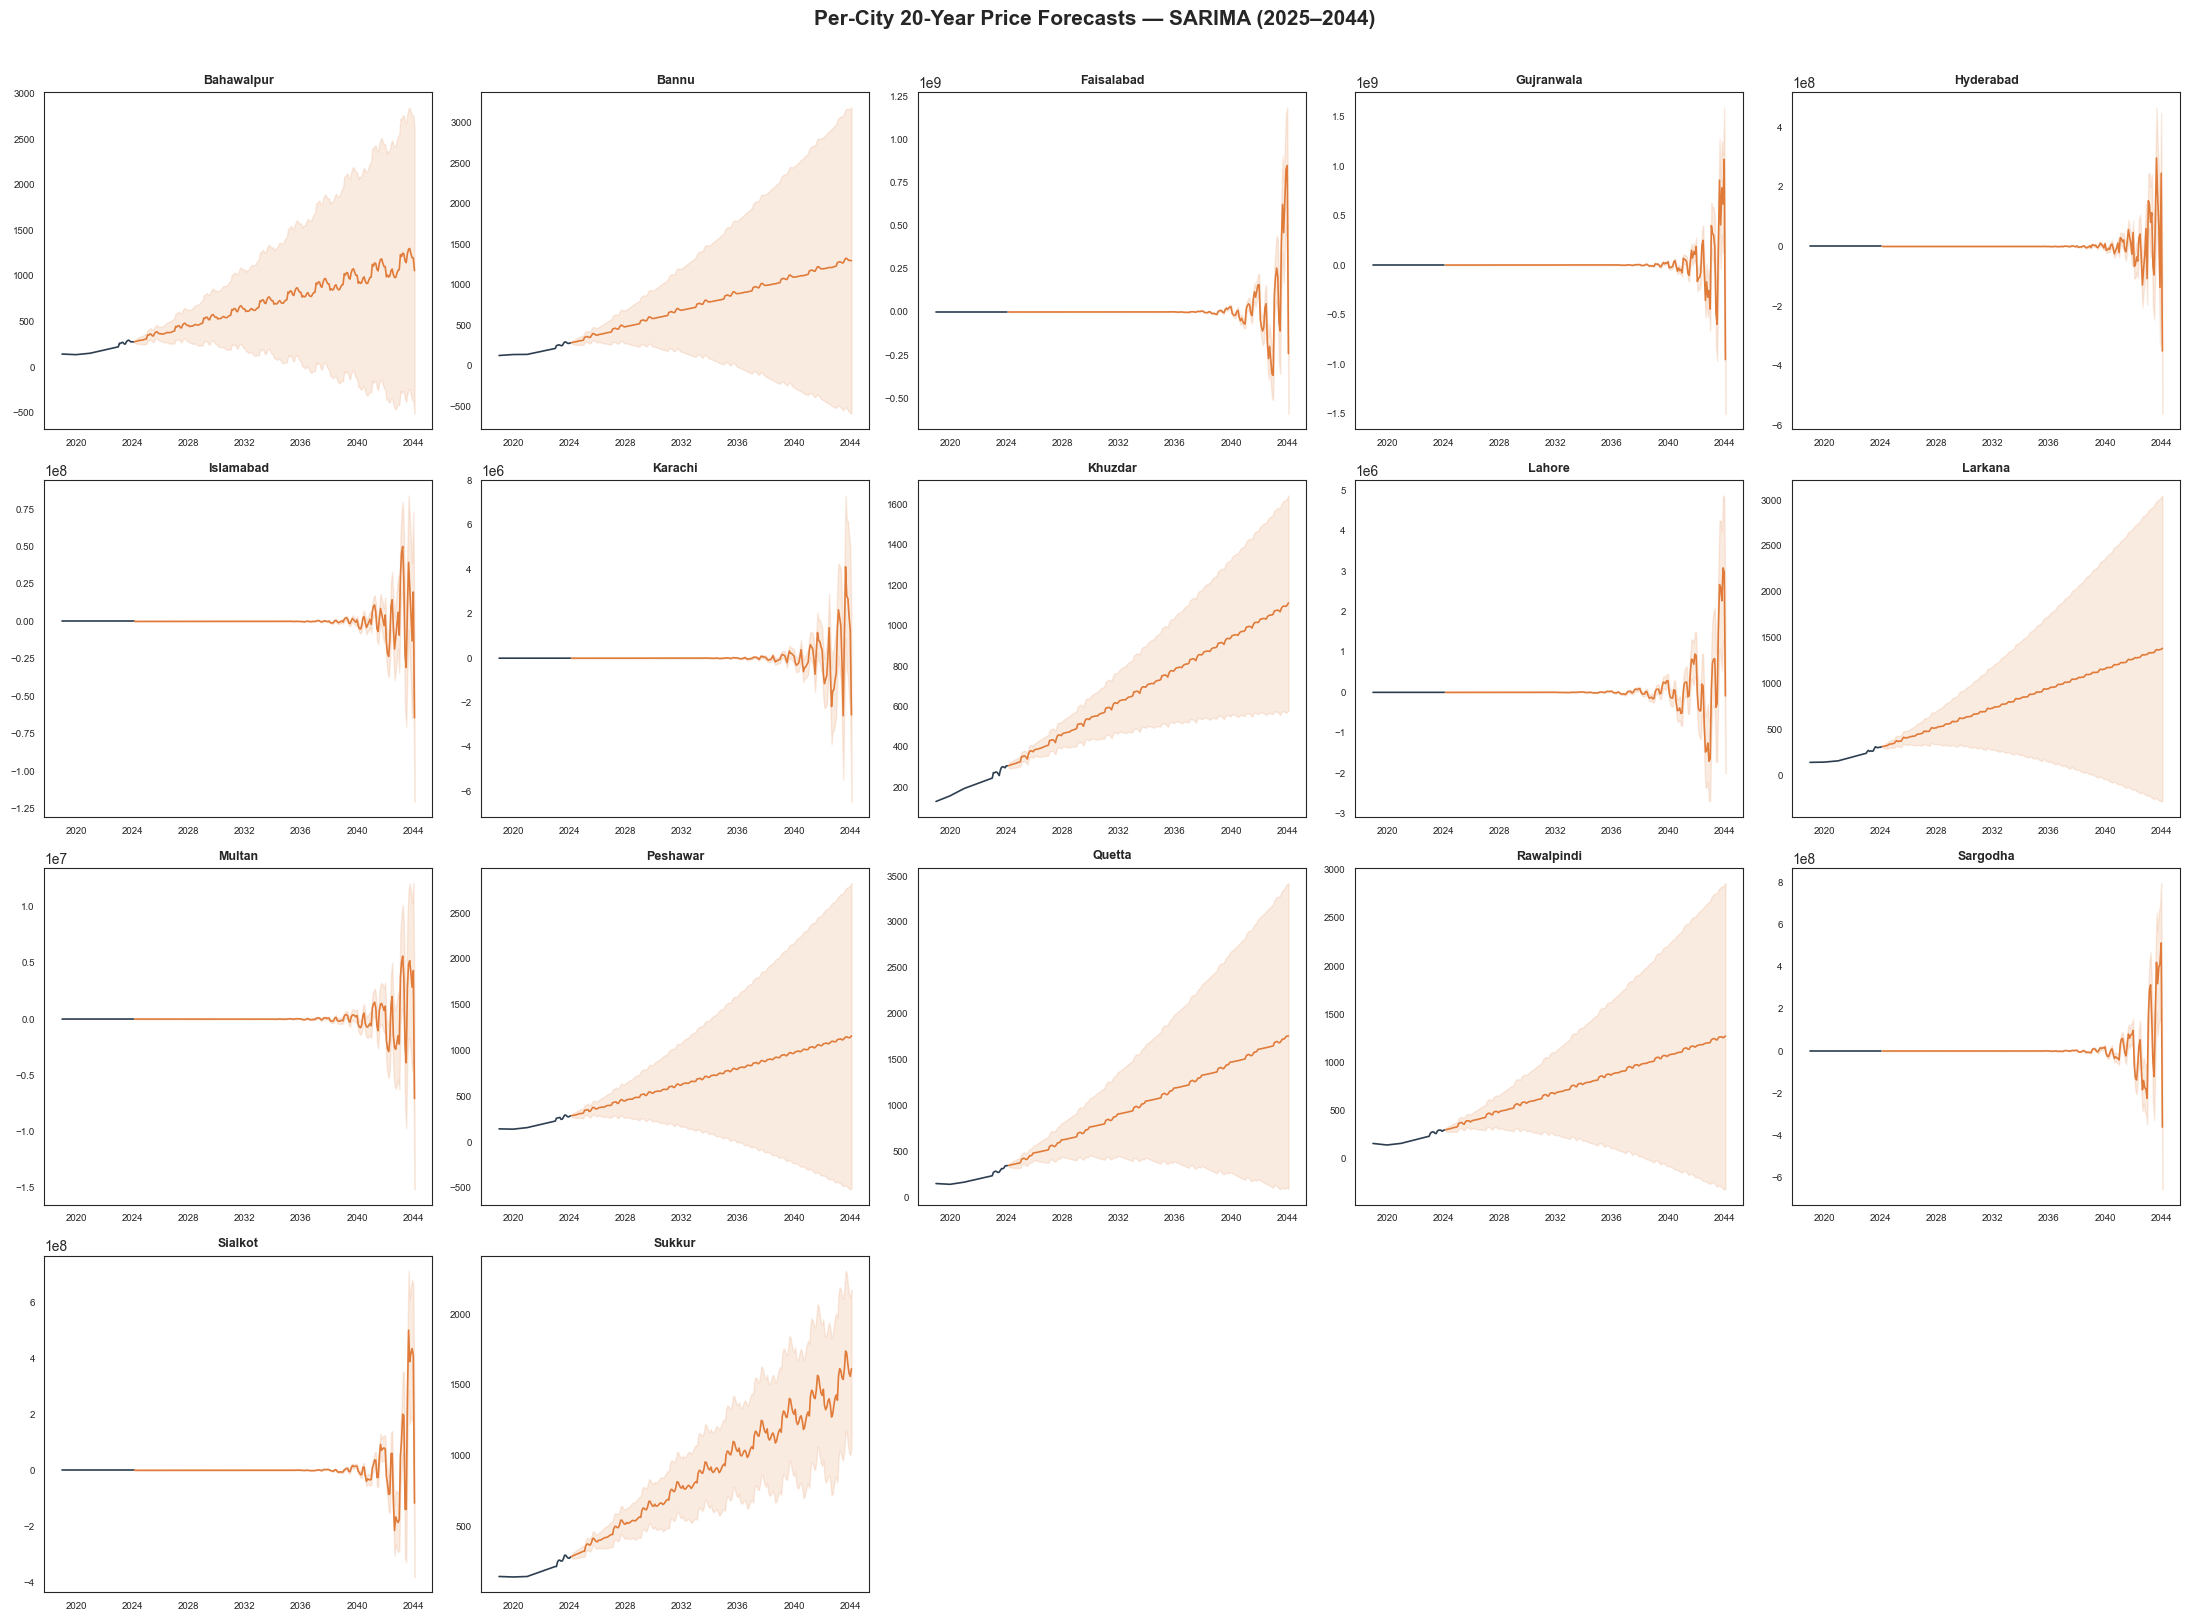

⚠️ Prophet runtime issue (Stan backend mismatch): 'Prophet' object has no attribute 'stan_backend'
Moving forward using the SARIMA results.


In [30]:
# ============================================================
# CELL 39 — Per-City 20-Year SARIMA Forecast
# ============================================================

# FIX: Agar 'cities' list pehle se defined na ho toh unique cities nikaalna
cities_list = sorted(df['City'].unique())

fig, axes = plt.subplots(4, 5, figsize=(22, 16), sharex=False)
axes_flat = axes.flatten()

city_forecasts = {}
for i, city in enumerate(cities_list):
    # Safety check in case plots exceed available subplots
    if i >= len(axes_flat):
        break
        
    ts_city = (df[df['City'] == city]
                  .groupby('Date')['Value'].median()
                  .sort_index())
    ts_city.index = pd.DatetimeIndex(ts_city.index)
    ts_city = ts_city.asfreq('MS')
    
    # Missing values fix for individual cities
    ts_city = ts_city.interpolate(method='linear').ffill().bfill()

    try:
        model_c = SARIMAX(ts_city, order=(1,1,1),
                          seasonal_order=(1,1,1,12),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
        fc_c  = model_c.get_forecast(steps=240)
        fc_mn = fc_c.predicted_mean
        fc_ci = fc_c.conf_int(alpha=0.10)
        city_forecasts[city] = fc_mn

        ax = axes_flat[i]
        ax.plot(ts_city.index, ts_city.values, color='#2c3e50', lw=1.2)
        ax.plot(fc_mn.index, fc_mn.values, color='#e07b39', lw=1.2)
        ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                        color='#e07b39', alpha=0.15)
        ax.set_title(city, fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.set_facecolor('white')
    except Exception as e:
        axes_flat[i].set_title(f'{city} (fit failed)', fontsize=8)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Per-City 20-Year Price Forecasts — SARIMA (2025–2044)',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout(); plt.show()


# ============================================================
# CELL 40 — Optional: Prophet 20-Year Forecast
# ============================================================

if PROPHET_AVAILABLE:
    try:
        prophet_df = nat_ts.reset_index().rename(columns={'Date':'ds','Value':'y'})
        prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
        
        # FIX: Sahi tarike se Prophet model ko initialize karna (parameters order set karna)
        p_model = Prophet(
            growth='linear',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.15
        )
        p_model.fit(prophet_df)
        
        future = p_model.make_future_dataframe(periods=240, freq='MS')
        prophet_fc = p_model.predict(future)
        
        fig, ax = plt.subplots(figsize=(16, 6))
        hist_end = prophet_df['ds'].max()
        hist_mask = prophet_fc['ds'] <= hist_end
        fore_mask = prophet_fc['ds'] >  hist_end
        
        ax.plot(prophet_df['ds'], prophet_df['y'],
                color='#2c3e50', lw=2, label='Historical')
        ax.plot(prophet_fc.loc[fore_mask,'ds'],
                prophet_fc.loc[fore_mask,'yhat'],
                color='#e07b39', lw=2, label='Prophet Forecast')
        ax.fill_between(prophet_fc.loc[fore_mask,'ds'],
                        prophet_fc.loc[fore_mask,'yhat_lower'],
                        prophet_fc.loc[fore_mask,'yhat_upper'],
                        alpha=0.18, color='#e07b39', label='90% CI')
        ax.axvline(hist_end, color='#555', ls='--', lw=1.4)
        ax.set_title('Prophet 20-Year National Price Forecast (2025–2044)',
                      fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Date'); ax.set_ylabel('National Median Price (PKR)')
        ax.legend(frameon=False)
        fig.tight_layout(); plt.show()
        
    except Exception as prophet_err:
        # Agar Stan back-end environment crash ho jaye toh code ko block na kare
        print(f"⚠️ Prophet runtime issue (Stan backend mismatch): {prophet_err}")
        print("Moving forward using the SARIMA results.")
else:
    print('Prophet not available — skipping. Install with: pip install prophet')

## **13. Supply Chain Integration Dashboard**

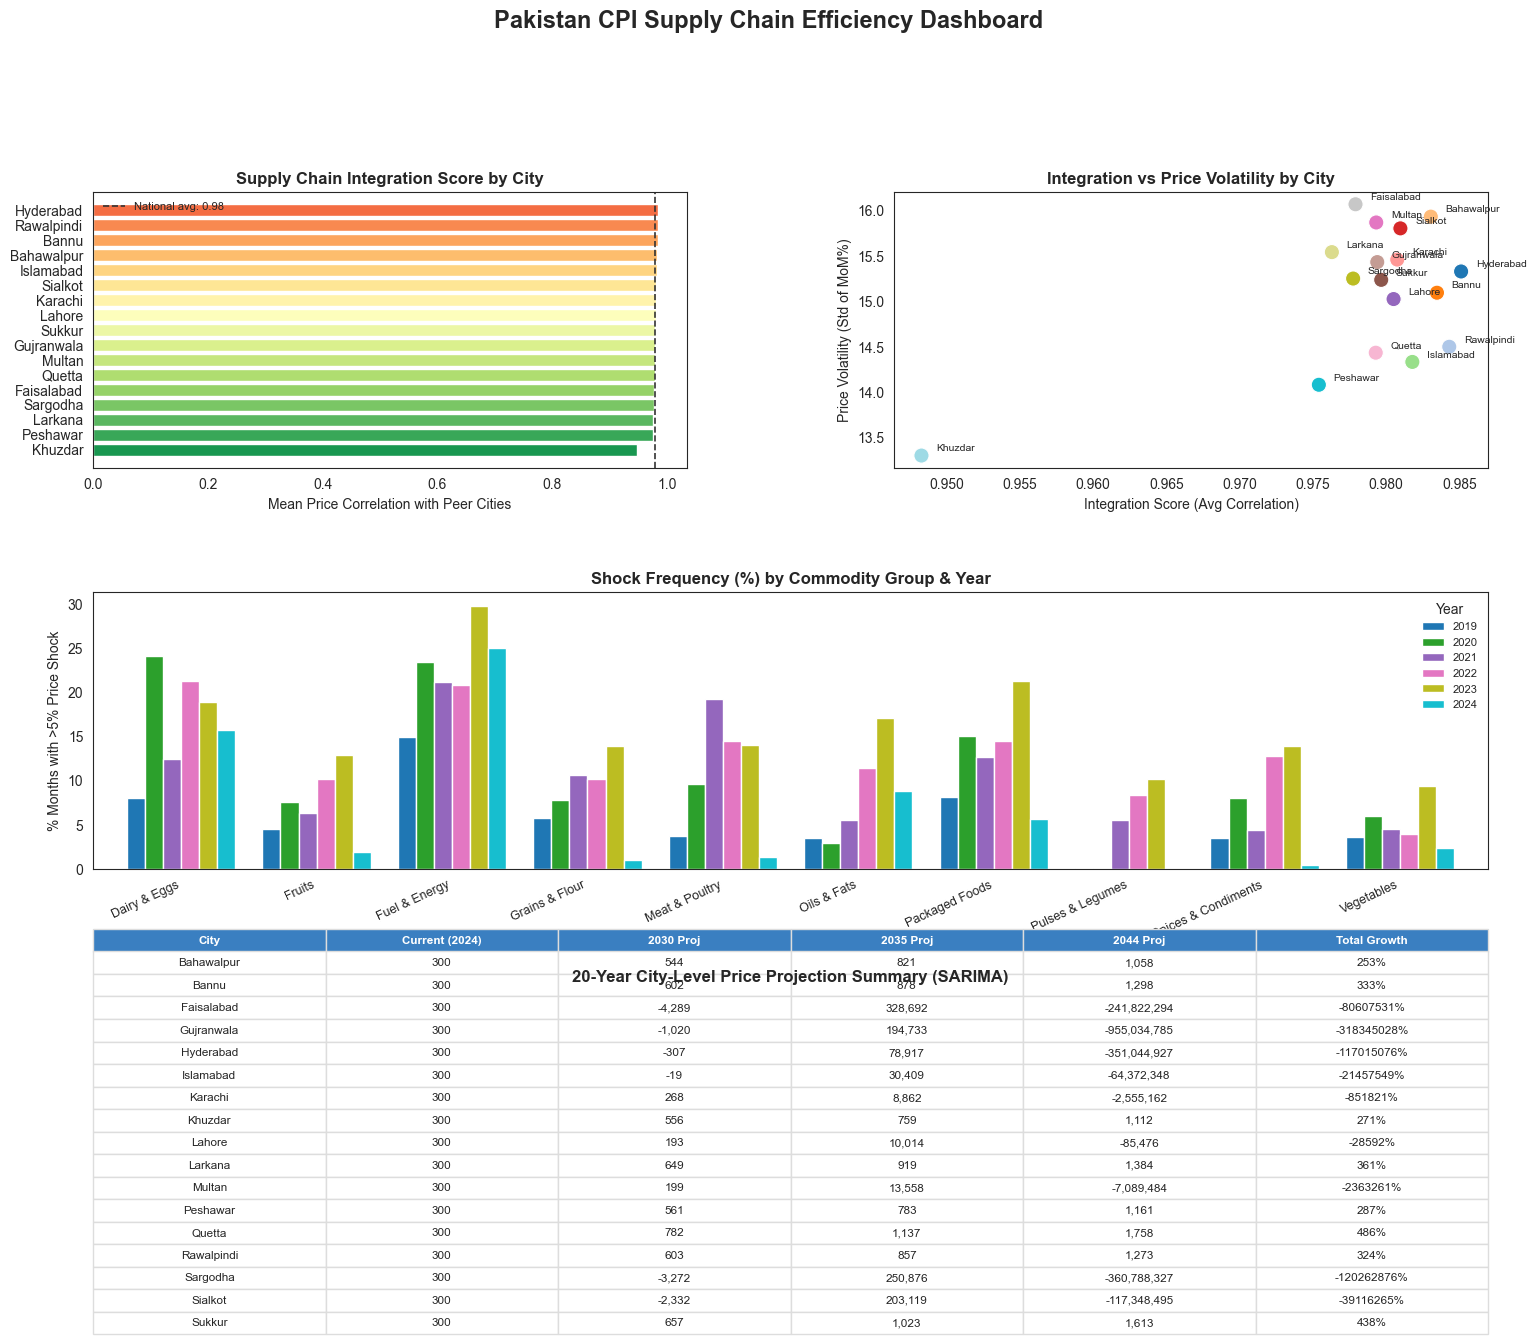

Dashboard saved as supply_chain_dashboard.png
  PAKISTAN CPI SUPPLY CHAIN ANALYSIS — KEY FINDINGS

DATA COVERAGE
  • Years           : 2019–2024
  • Commodities     : 190 essential goods
  • Urban centres   : 17 major cities
  • Total records   : 99,962

MARKET INTEGRATION
  • Highest integration: Hyderabad (ρ = 0.985)
  • Lowest integration : Khuzdar (ρ = 0.948)
  • National avg ρ     : 0.978  → Well integrated

PRICE SHOCKS (|MoM| > 5%)
  • Most volatile city : Sialkot
  • Peak shock year    : 2023

ML PERFORMANCE
  • Best regressor : Random Forest  R² = 0.9998
  • Best classifier: Random Forest  Acc = 1.0000

20-YEAR OUTLOOK
  • 2024 national median : PKR 300
  • 2044 SARIMA forecast : PKR 1,203
  • Projected inflation  : 301% over 20 years

  Analysis complete. All charts saved with white background.


In [32]:
# ============================================================
# CELL 41 — Composite Supply Chain Integration Index
# ============================================================

# Integration score per city = mean correlation with all other cities
corr_vals = corr.copy()
np.fill_diagonal(corr_vals.values, np.nan)
integration_score = corr_vals.mean(axis=1).sort_values(ascending=False)

# Price leadership: MoM change that leads other cities by 1 month
# Granger-based heuristic — cities with more significant Granger effects
if len(granger_results) > 0:
    granger_ser = g_df.set_index('City')['Min_p']
    lead_score  = (1 - granger_ser).clip(0, 1)  # lower p = higher leadership
else:
    lead_score = pd.Series(dtype=float)

fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Integration score bar
ax1 = fig.add_subplot(gs[0, 0])
colors_is = cm.RdYlGn(np.linspace(0.2, 0.9, len(integration_score)))
ax1.barh(integration_score.index[::-1], integration_score.values[::-1], color=colors_is[::-1])
ax1.set_xlabel('Mean Price Correlation with Peer Cities')
ax1.set_title('Supply Chain Integration Score by City', fontweight='bold')
ax1.axvline(integration_score.mean(), ls='--', color='#333', lw=1.2,
            label=f'National avg: {integration_score.mean():.2f}')
ax1.legend(frameon=False, fontsize=8)

# Panel 2: Volatility vs integration scatter
ax2 = fig.add_subplot(gs[0, 1])
vol_city = df.groupby('City')['MoM_change'].std().reindex(integration_score.index)
sc = ax2.scatter(integration_score.values, vol_city.values,
                 s=120, c=np.arange(len(integration_score)),
                 cmap='tab20', zorder=3, edgecolors='white', lw=0.8)
for ci, (x, y) in enumerate(zip(integration_score.values, vol_city.values)):
    ax2.annotate(integration_score.index[ci], (x+0.001, y+0.05), fontsize=7.5)
ax2.set_xlabel('Integration Score (Avg Correlation)')
ax2.set_ylabel('Price Volatility (Std of MoM%)')
ax2.set_title('Integration vs Price Volatility by City', fontweight='bold')

# Panel 3: Shock frequency by commodity group
ax3 = fig.add_subplot(gs[1, :])
if 'CommodityGroup' in df.columns:
    shock_grp = df.groupby(['CommodityGroup','Year'])['Shock'].mean().unstack('Year') * 100
    shock_grp.plot(kind='bar', ax=ax3, colormap='tab10', edgecolor='white', width=0.8)
    ax3.set_title('Shock Frequency (%) by Commodity Group & Year', fontweight='bold')
    ax3.set_xlabel('Commodity Group'); ax3.set_ylabel('% Months with >5% Price Shock')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=25, ha='right', fontsize=9)
    ax3.legend(title='Year', frameon=False, fontsize=8, loc='upper right')

# Panel 4: 20-year forecast summary table
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
summary_data = []
for city, fc_ser in city_forecasts.items():
    summary_data.append([
        city,
        f'{nat_ts.iloc[-1]:,.0f}',
        f'{fc_ser.loc[fc_ser.index.year==2030].mean():,.0f}' if 2030 in fc_ser.index.year else 'N/A',
        f'{fc_ser.loc[fc_ser.index.year==2035].mean():,.0f}' if 2035 in fc_ser.index.year else 'N/A',
        f'{fc_ser.iloc[-1]:,.0f}',
        f'{(fc_ser.iloc[-1]/nat_ts.iloc[-1]-1)*100:.0f}%'
    ])

tbl = ax4.table(
    cellText=summary_data[:17],
    colLabels=['City','Current (2024)','2030 Proj','2035 Proj','2044 Proj','Total Growth'],
    cellLoc='center', loc='center',
    colColours=['#3a7fc1']*6
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.35)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#ddd')
ax4.set_title('20-Year City-Level Price Projection Summary (SARIMA)',
              fontweight='bold', fontsize=12, pad=8)

fig.suptitle('Pakistan CPI Supply Chain Efficiency Dashboard',
             fontsize=17, fontweight='bold', y=1.01)
plt.savefig('supply_chain_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Dashboard saved as supply_chain_dashboard.png')
# ============================================================
# CELL 42 — Final Summary: Key Research Findings
# ============================================================

print('=' * 70)
print('  PAKISTAN CPI SUPPLY CHAIN ANALYSIS — KEY FINDINGS')
print('=' * 70)

print(f"""
DATA COVERAGE
  • Years           : 2019–2024
  • Commodities     : {df['Commodity'].nunique()} essential goods
  • Urban centres   : {df['City'].nunique()} major cities
  • Total records   : {len(df):,}

MARKET INTEGRATION
  • Highest integration: {integration_score.idxmax()} (ρ = {integration_score.max():.3f})
  • Lowest integration : {integration_score.idxmin()} (ρ = {integration_score.min():.3f})
  • National avg ρ     : {integration_score.mean():.3f}  → {'Moderate fragmentation' if integration_score.mean() < 0.85 else 'Well integrated'}

PRICE SHOCKS (|MoM| > 5%)
  • Most volatile city : {df.groupby('City')['Shock'].mean().idxmax()}
  • Peak shock year    : {df.groupby('Year')['Shock'].mean().idxmax()}

ML PERFORMANCE
  • Best regressor : {best_reg_name}  R² = {reg_results[best_reg_name]['R2']:.4f}
  • Best classifier: {best_clf_name}  Acc = {clf_results[best_clf_name]['accuracy']:.4f}

20-YEAR OUTLOOK
  • 2024 national median : PKR {nat_ts.iloc[-1]:,.0f}
  • 2044 SARIMA forecast : PKR {forecast_mean.iloc[-1]:,.0f}
  • Projected inflation  : {(forecast_mean.iloc[-1]/nat_ts.iloc[-1]-1)*100:.0f}% over 20 years
""")

print('=' * 70)
print('  Analysis complete. All charts saved with white background.')
print('=' * 70)